# 1. Importamos las librerias:
Correr esta celda si no se tiene estas librerias:

In [1]:
#pip install requests geopandas matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import requests
import re
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Cargamos el df:

In [3]:
df_maestro = pd.read_csv('https://media.githubusercontent.com/media/clararodriguezacevedo/descriptiva-real-estate/refs/heads/main/data/raw/dataframe_maestro.tsv', sep='\t')

Revisamos si se cargo bien:

In [4]:
df_maestro.head()

,Fecha_Scraping,Posting_ID,Sito,Operación,Precio,Expensas,Calle,Altura,Piso,Barrio,...,Descripción,Link,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
0,2026-04-12,58757240,zonaprop,alquiler,$ 750.000,$ 300.000,Mansilla,2936.0,NaN,Barrio Norte,...,Amplio departamento de dos ambientes en el exc...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,0,0,1,0
1,2026-04-12,58818211,zonaprop,alquiler,$ 1.700.000,$ 400.000,Cespedes,2300.0,NaN,Belgrano,...,"3 ambientes con balcón, y terraza con parrilla...",https://www.zonaprop.com.ar/propiedades/clasif...,1,0,0,0,1,0,0,0
2,2026-04-12,58564550,zonaprop,alquiler,USD 2.500,$ 1.150.000,Riobamba,1200.0,NaN,Recoleta,...,Departamento en alquiler de 4 ambientes con co...,https://www.zonaprop.com.ar/propiedades/clasif...,4,0,0,0,1,1,1,0
3,2026-04-12,58314210,zonaprop,alquiler,USD 1.300,NaN,Pereyra Lucena,2500.0,NaN,Palermo,...,Amoblado y Equipado. Ubicado a metros de Av. L...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,1,0,1,1
4,2026-04-12,58810878,zonaprop,alquiler,USD 3.800,NaN,Lola Mora,400.0,NaN,Puerto Madero,...,Alquiler temporario de 3 ambientes amueblado e...,https://www.zonaprop.com.ar/propiedades/clasif...,3,0,0,0,1,1,0,0


In [5]:
df_maestro.shape

(66180, 21)

Hacemos una copia para no manipular el df original:

In [6]:
df = df_maestro.copy()

# 3. Análisis Inicial

## Variables Categoricas y Numericas:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66180 entries, 0 to 66179
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha_Scraping     66180 non-null  object 
 1   Posting_ID         66180 non-null  int64  
 2   Sito               66180 non-null  object 
 3   Operación          66180 non-null  object 
 4   Precio             66180 non-null  object 
 5   Expensas           45549 non-null  object 
 6   Calle              60722 non-null  object 
 7   Altura             60722 non-null  float64
 8   Piso               15167 non-null  object 
 9   Barrio             66180 non-null  object 
 10  Detalles           65957 non-null  object 
 11  Descripción        65868 non-null  object 
 12  Link               66180 non-null  object 
 13  Amenities          66180 non-null  int64  
 14  Losa_Central       66180 non-null  int64  
 15  Aire_Acond         66180 non-null  int64  
 16  Apto_Credito       661

Decir algo de variables categoricas vs numericas ...

In [8]:
df.columns

Index(['Fecha_Scraping', 'Posting_ID', 'Sito', 'Operación', 'Precio',
       'Expensas', 'Calle', 'Altura', 'Piso', 'Barrio', 'Detalles',
       'Descripción', 'Link', 'Amenities', 'Losa_Central', 'Aire_Acond',
       'Apto_Credito', 'Cochera', 'Seguridad', 'Luminoso',
       'Balcon_Aterrazado'],
      dtype='object')

In [9]:
df.describe()

,Posting_ID,Altura,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
count,6.618000e+04,60722.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000
mean,3.692180e+07,2255.691726,1.272635,0.097749,0.316893,0.072983,0.288697,0.213796,0.601224,0.091674
std,2.008695e+07,1714.396910,1.714579,0.296977,0.465269,0.260110,0.453160,0.409987,0.489650,0.288568
min,1.527159e+06,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.863395e+07,950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.938779e+07,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,5.842992e+07,3100.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,5.882838e+07,54300.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Normalizamos:

Los nombres de las columnas:

In [10]:
df = df.rename(columns={"Sito": "sitio","Operación": "operacion"})

In [11]:
df.columns = (df.columns.str.lower())

Los títulos de los barrios para realizar diferentes analisis mas adelante:

In [12]:
mapeo = {
    "Palermo Nuevo": "Palermo",
    "Palermo Viejo": "Palermo",
    "Palermo Hollywood": "Palermo",
    "Palermo Soho": "Palermo",
    "Palermo Chico": "Palermo",
    "Las Cañitas": "Palermo",
    "Botanico": "Palermo",
    "Botánico": "Palermo",

    "Belgrano R": "Belgrano",
    "Belgrano C": "Belgrano",
    "Belgrano Chico": "Belgrano",
    "Belgrano Barrancas": "Belgrano",
    "Barrio Chino": "Belgrano",

    "Almagro Norte": "Almagro",
    "Almagro Sur": "Almagro",
    "Abasto": "Almagro",

    "Caballito Norte": "Caballito",
    "Caballito Sur": "Caballito",
    "Parque Rivadavia": "Caballito",
    "Primera Junta": "Caballito",
    "Cid Campeador": "Caballito",

    "Flores Norte": "Flores",
    "Flores Sur": "Flores",

    "Floresta Norte": "Floresta",
    "Floresta Sur": "Floresta",

    "Centro": "San Nicolas",
    "Microcentro": "San Nicolas",
    "Centro / Microcentro": "San Nicolas",
    "San Nicolás": "San Nicolas",
    "Tribunales": "San Nicolas",
    "Congreso": "San Nicolas",

    "Núñez": "Nuñez",
    "Lomas De Núñez": "Nuñez",
    "Lomas De Nuñez": "Nuñez",
    "River": "Nuñez",

    "Constitución": "Constitucion",
    "Concepción": "San Cristobal",
    "Once": "Balvanera",
    "Pompeya": "Nueva Pompeya",

    "Barrio Norte": "Recoleta",
    "Plaza San Martín": "Retiro",
    "Catalinas": "Retiro",
    "Puerto Retiro": "Retiro",

    "Parque Centenario": "Caballito",
    "Parque Las Heras": "Palermo",

    "Urquiza R": "Villa Urquiza",

    "Villa Pueyrredón": "Villa Pueyrredon",
    "Villa General Mitre": 'Villa Gral. Mitre',
    "La Paternal": "La Paternal",
    "Paternal": "La Paternal",
    "Los Perales": "Mataderos",
    "Agronomía": "Agronomia",

    "Boca": "La Boca",

    "Barrio Norte": "Recoleta",
    "Barrio Parque Saavedra": "Saavedra",
    "Barrio Parque General Belgrano": "Belgrano",
    "Barrio San Pedro": "Saavedra",
    "Barrio Justo Suarez": "Villa Urquiza",
    "Barrio Naón": "Agronomia",
    "Naón": "Agronomia",
    "Barrio Parque": "Palermo",
    "Distrito Quartier": "Puerto Madero",

    "Otro": None, 
}

df["barrio_norm"] = df["barrio"].str.strip().str.title()
df["barrio_oficial"] = df["barrio_norm"].replace(mapeo)

## Vemos duplicados:

Revisamos las filas duplicadas y eliminamos los registros idénticos

In [13]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 3243


In [14]:
df = df.drop_duplicates(keep = 'first').reset_index(drop=True)

In [15]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 0


# 4. Tratamos las columnas precio y expensas

### Precio:

Vemos cuales son los signos que acompañan al precio:

In [16]:
df_prueba = df.copy()
# Aseguramos que sea string y quitamos espacios en blanco extremos
df_prueba['columna_precio'] = df_prueba['precio'].astype(str).str.strip()

# Para el PRECIO: Quitamos TODO lo que no sea número, coma o punto
df_prueba['precio_num'] = df_prueba['columna_precio'].str.replace(r'[^0-9,\.]', '', regex=True)

# Para la MONEDA: Quitamos números, puntos, comas y espacios
# Esto te va a dejar solo los caracteres como USD, ARS, $, etc.
df_prueba['simbolo_detectado'] = df_prueba['columna_precio'].str.replace(r'[0-9,\.\s]', '', regex=True)

# Verificamos qué quedó
print(df_prueba['simbolo_detectado'].unique())

['$' 'USD' 'Consultar']


Los unicos valores detectados son '$' 'USD' 'Consultar'. Entonces, consideramos que los precios que leen 'USD' son los que están en dólares, y los que no los que estan en Pesos. Dejamos en NAN los que pongan consultar, para tratarlo mas adelante.

In [17]:
import re

# Detectamos la moneda a partir del texto del precio, incluyendo variaciones comunes
patron_usd = r'usd|u\$s|u\$d|us\$|dolar(es)?|dollar(s)?'

df['moneda'] = df['precio'].apply(
    lambda x: 'usd' if re.search(patron_usd, str(x).lower()) else 'ars'
)

print("Distribución de monedas detectadas:")
print(df['moneda'].value_counts())

Distribución de monedas detectadas:
moneda
usd    46128
ars    16809
Name: count, dtype: int64


In [18]:
# Limpiamos el texto del precio eliminando todos los indicadores de moneda y símbolos
df['precio'] = (
    df['precio']
    .astype(str)
    .str.lower()
    .str.replace(r'u\$s|u\$d|us\$', '', regex=True)
    .str.replace('usd', '', regex=False)
    .str.replace('ars', '', regex=False)
    .str.replace('dolares', '', regex=False)
    .str.replace('dolar', '', regex=False)
    .str.replace('dollars', '', regex=False)
    .str.replace('dollar', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)
df['precio'] = df['precio'].apply(lambda x: float(x) if x != 'consultar' and x != '' else np.nan)

### Expensas:

In [19]:
# 1. Aseguramos que la columna de expensas sea string
df_prueba['expensas_raw'] = df_prueba['expensas'].astype(str).str.strip().str.lower()

# 2. Extraemos solo los números
df_prueba['expensas_num_sucio'] = df_prueba['expensas_raw'].str.replace(r'[^0-9,\.]', '', regex=True)

# 3. Detectamos si había texto útil 
df_prueba['expensas_texto'] = df_prueba['expensas_raw'].str.replace(r'[0-9,\.\s]', '', regex=True)

print("\nValores de texto encontrados en expensas:")
print(df_prueba['expensas_texto'].unique())


Valores de texto encontrados en expensas:
['$' 'nan']


Vemos que las expensas están siempre expresadas en pesos, entonces:

In [20]:
df['expensas'] = (df['expensas'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['expensas'] = df["expensas"].apply(lambda x: float(x) if x != '' else np.nan)

### Analizamos:

In [21]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda

count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14458  8.282753e+05  700000.0  9.965850e+05   
       alquiler_temporal    810  7.122810e+05  750000.0  3.849273e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6879  5.346962e+03    1200.0  5.369935e+04   
       alquiler_temporal   6065  5.744404e+03     850.0  2.247339e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler               1.0  111111111.0  
       alquiler_temporal      1.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      5.0   12322222.0  
       venta                  1.0   12000000.0

### Observación sobre valores mínimos y máximos ficticios

Se puede observar que prácticamente todos los segmentos (moneda × operación) presentan un mínimo de 1 o valores extremadamente bajos. Estos no son precios reales: corresponden a publicaciones donde el vendedor o intermediario no quiso revelar el precio y utilizó un valor simbólico (como "1 peso") como marcador de posición (placeholder*.

De manera análoga, los valores máximos extremos como 111.111.111 ARS o 12.322.222 USD pueden ser artificiales. Es una práctica habitual en portales inmobiliarios ingresar valores como "111111111" o "999999999" para indicar que el precio está a consultar, en lugar de dejar el campo vacío.

Estos valores ficticios distorsionan cualquier análisis estadístico (medias, desvíos, visualizaciones), entonces es necesario removerlos con un proceso de detección de outliers.

### Visualización de precios por segmento

Graficar todos los segmentos en un mismo eje sería engañoso: los precios en ARS y en USD difieren en órdenes de magnitud, y los alquileres y ventas tampoco son comparables entre sí. Por eso utilizamos subplots independientes con escala libre en cada eje, de modo que cada combinación (moneda × operación) sea legible por separado.

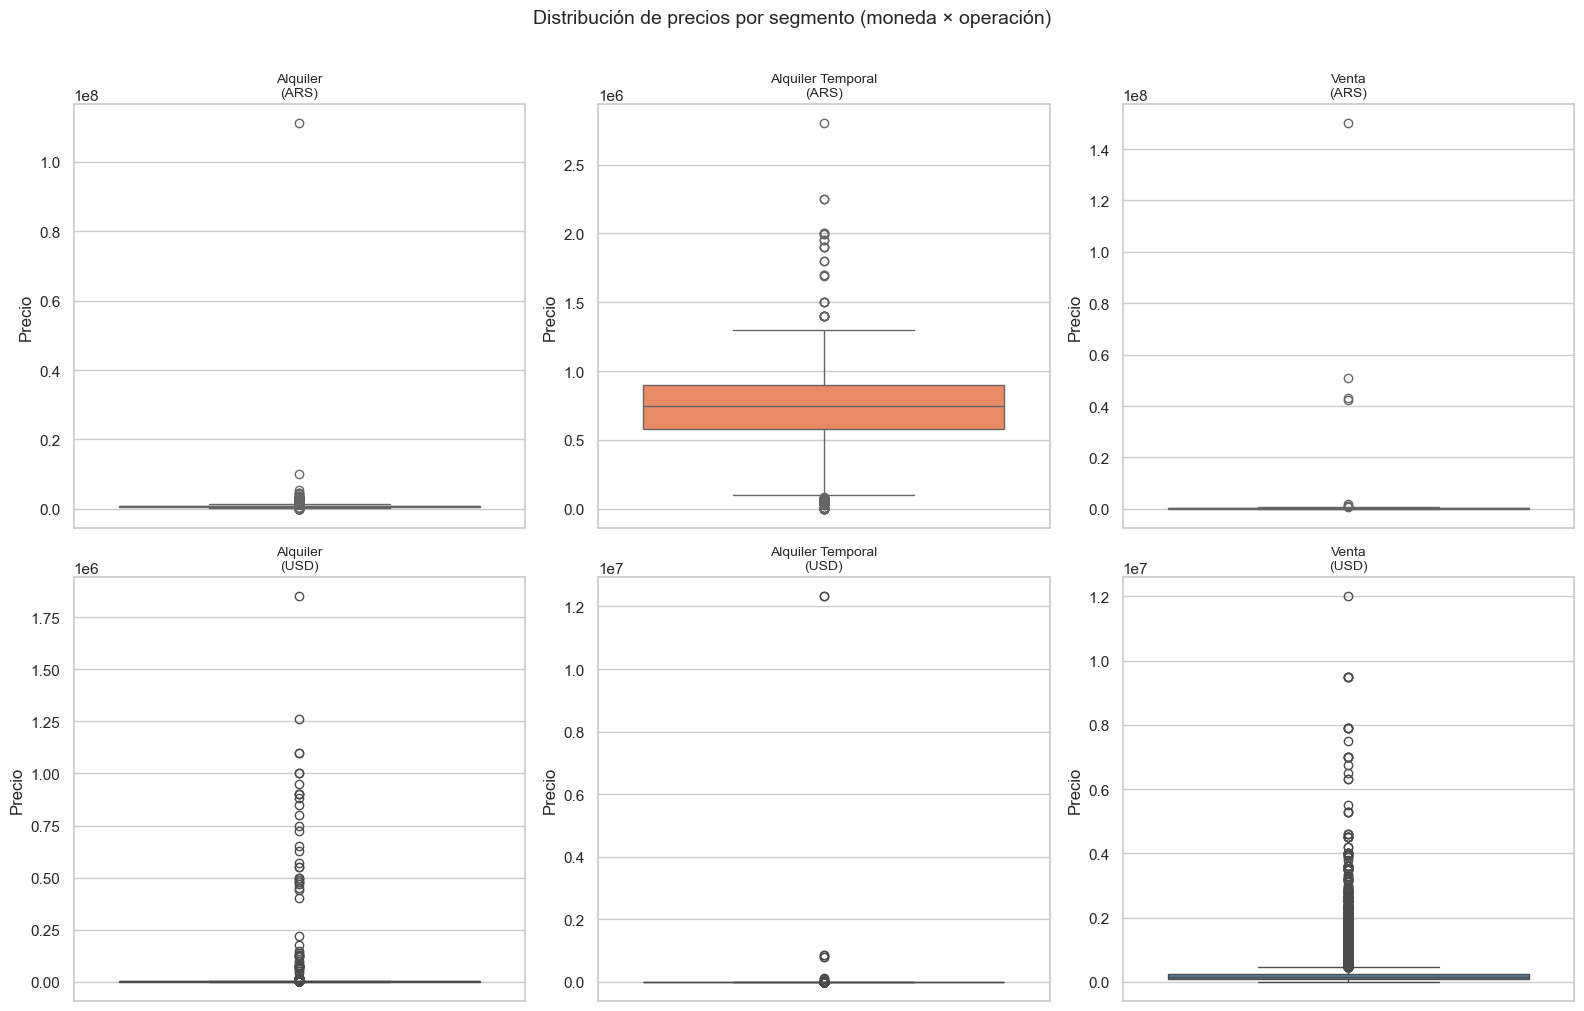

In [22]:
df_plot = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# Definimos los segmentos a graficar
monedas = ['ars', 'usd']
operaciones = ['alquiler', 'alquiler_temporal', 'venta']

fig, axes = plt.subplots(
    nrows=len(monedas),
    ncols=len(operaciones),
    figsize=(16, 10),
    sharex=False,
    sharey=False
)

for i, moneda in enumerate(monedas):
    for j, operacion in enumerate(operaciones):
        ax = axes[i][j]
        subset = df_plot[(df_plot['moneda'] == moneda) & (df_plot['operacion'] == operacion)]['precio'].dropna()

        if len(subset) > 0:
            sns.boxplot(y=subset, ax=ax, color='steelblue' if moneda == 'usd' else 'coral')
            ax.set_title(f"{operacion.replace('_', ' ').title()}\n({moneda.upper()})", fontsize=10)
        else:
            ax.set_visible(False)

        ax.set_xlabel("")
        ax.set_ylabel("Precio")

fig.suptitle("Distribución de precios por segmento (moneda × operación)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

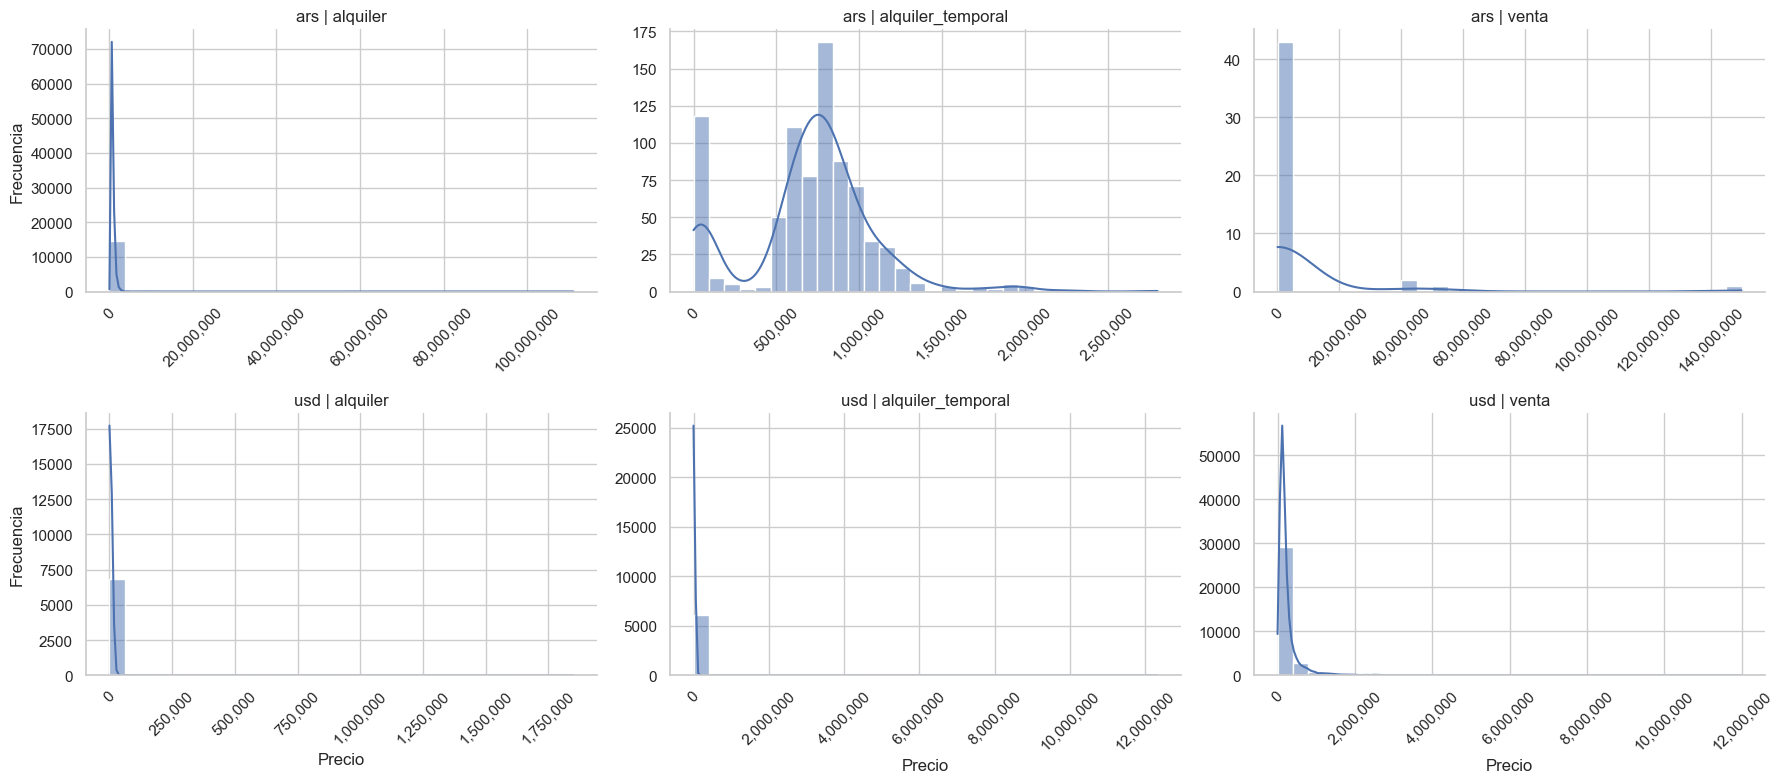

In [23]:
import matplotlib.ticker as ticker

df_precio = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# 1. Crear el FacetGrid
g = sns.FacetGrid(df_precio, row="moneda", col="operacion", 
                  sharex=False, sharey=False, height=4, aspect=1.5)

# 2. Mapear el histograma
g.map_dataframe(sns.histplot, x="precio", bins=30, kde=True)

# 3. Ajustar cada subgráfico individualmente
for ax in g.axes.flat:
    # Quitar la notación científica (1e8, etc.)
    ax.ticklabel_format(style='plain', axis='x')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # Rotar las etiquetas si son muy largas
    ax.tick_params(axis='x', rotation=45)

g.set_axis_labels("Precio", "Frecuencia")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()

En muchos de los gráficos, la gran mayoría de los registros se agrupan en una única barra cerca del cero. Esto sucede porque el eje x se extiende automáticamente para alcanzar outliers, dejando el "mercado real" comprimido en un espacio reducido.

Además, las curvas de densidad se ven como líneas verticales que caen abruptamente, lo que impide analizar la distribución normal, la moda o la dispersión de los precios comunes.

# 5. Feature Engineering - Parseo de texto y KPIs

Extraemos variables estructuradas a partir de las columnas de texto libre `detalles` y `descripción` mediante expresiones regulares. Luego materializamos los KPIs definidos en la entrega anterior.

In [24]:
detalles = df['detalles'].unique()
print(detalles)

['60 m² tot. 2 amb. 1 dorm. 1 baño'
 '114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.'
 '121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.' ...
 '111 m² cubie. 2 dorm. 2 baños' '90 m² cubie. 3 dorm. 27 años'
 '99 m² cubie. 2 dorm. 95 años']


Los detalles pueden incluir distintos datos, pero decidimos solo extraer m², ambientes, dormitorios, baños y antigüedad, que son las variables numericas que necesitamos. 

Las demas, las obtenemos de descripcion, como variables binarias o categoricas (si en la descripcion encontramos cada uno de los valores). 

## Funciones

In [25]:
import pandas as pd
import re

def parse_detalles(s):
    """Parsea la columna 'detalles' de ZonaProp/ArgEnProp en columnas individuales."""
    if pd.isna(s):
        return {}
    result = {}

    # Superficie total (ej: "60 m² tot." o "60 m² cubie.")
    m_tot = re.search(r'([\d,\.]+)\s*m²\s*tot\.?', s)
    m_cub = re.search(r'([\d,\.]+)\s*m²\s*cubie\.?', s)
    if m_tot:
        result['m2_total'] = float(m_tot.group(1).replace(',', '.'))
    elif m_cub:
        result['m2_total'] = float(m_cub.group(1).replace(',', '.'))

    # Ambientes (ej: "3 amb." o "3 ambientes")
    amb = re.search(r'(\d+)\s*amb\.', s)
    ambientes = re.search(r'(\d+)\s*ambientes', s)
    if amb:
        result['ambientes'] = int(amb.group(1))
    elif ambientes:
        result['ambientes'] = int(ambientes.group(1))

    # Dormitorios (ej: "2 dorm.")
    dorm = re.search(r'(\d+)\s*dorm\.', s)
    if dorm:
        result['dormitorios'] = int(dorm.group(1))

    # Baños (ej: "1 baño" o "2 baños")
    ban = re.search(r'(\d+)\s*baños?', s)
    if ban:
        result['baños'] = int(ban.group(1))
        
    # Antigüedad: 0 si "A estrenar", número si "X años"
    a_estrenar = re.search(r'A\s*[Ee]strenar', s)
    anios = re.search(r'(\d+)\s*años', s)
    if a_estrenar:
        result['antiguedad_años'] = 0
    elif anios:
        result['antiguedad_años'] = int(anios.group(1))

    return result

In [26]:
def parse_descripcion(s):
    if pd.isna(s):
        return {}
    
    s_low = s.lower()
    result = {}

    # --- Orientación ---
    if re.search(r'contra\s*frente|contrafrente', s_low):
        result['orientacion'] = 'Contra Frente'
    elif re.search(r'\bfrente\b', s_low):
        result['orientacion'] = 'Frente'
    elif re.search(r'\blateral\b', s_low):
        result['orientacion'] = 'Lateral'

    # --- Vista ---
    if re.search(r'vista\s*al?\s*r[ií]o', s_low):
        result['vista_rio'] = True
    if re.search(r'vista\s*al?\s*park|vista\s*verde|vista\s*jard[ií]n', s_low):
        result['vista_verde'] = True

    # --- Balcón ---
    if re.search(r'balc[oó]n', s_low):
        result['balcon'] = True

    # --- Terraza ---
    if re.search(r'terraza', s_low):
        result['terraza'] = True

    # --- Pileta ---
    if re.search(r'pileta|piscina', s_low):
        result['pileta'] = True

    # --- Parrilla ---
    if re.search(r'parrill[ao]', s_low):
        result['parrilla'] = True

    # --- SUM ---
    if re.search(r'\bsum\b|sal[oó]n\s*de\s*usos\s*m[uú]ltiples', s_low):
        result['sum'] = True

    # --- Laundry / Lavadero ---
    if re.search(r'laundry|lavadero', s_low):
        result['lavadero'] = True

    # --- Gimnasio ---
    if re.search(r'gimnasio|gym\b', s_low):
        result['gimnasio'] = True

    # --- Baulera ---
    if re.search(r'baulera', s_low):
        result['baulera'] = True

    # --- Calefacción ---
    if re.search(r'piso\s*radiante', s_low):
        result['calefaccion'] = 'Piso radiante'
    elif re.search(r'radiadores?', s_low):
        result['calefaccion'] = 'Radiadores'
    elif re.search(r'calefacci[oó]n\s*central', s_low):
        result['calefaccion'] = 'Central'
    elif re.search(r'calefacci[oó]n', s_low):
        result['calefaccion'] = 'Sí'

    # --- Agua caliente central ---
    if re.search(r'agua\s*caliente\s*central', s_low):
        result['agua_caliente_central'] = True

    # --- Ascensor ---
    if re.search(r'sin\s*ascensor|no\s*tiene\s*ascensor', s_low):
        result['ascensor'] = False
    elif re.search(r'ascensor', s_low):
        result['ascensor'] = True

    # --- Portero ---
    if re.search(r'portero\s*(?:el[eé]ctrico|visor|virtual)', s_low):
        result['portero'] = True


    # --- Apto profesional ---
    if re.search(r'no\s*apto\s*prof', s_low):
        result['apto_profesional'] = False
    elif re.search(r'apto\s*prof|apto\s*para\s*prof', s_low):
        result['apto_profesional'] = True

    # --- Mascotas ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:mascotas?|animales?)|no\s*mascotas?', s_low):
        result['permite_mascotas'] = 0
    elif re.search(r'acept[ao]\s*mascotas?|permite?\s*mascotas?|mascotas?\s*(?:ok|permitidas?)|apto\s*mascota', s_low):
        result['permite_mascotas'] = 1

    # --- Garantías ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = False
    elif re.search(r'(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = True
    if re.search(r'finaer', s_low):
        result['acepta_finaer'] = True

    # --- Financiación ---
    if re.search(r'financiaci[oó]n|financia\b', s_low):
        result['ofrece_financiacion'] = True

    # --- Accesibilidad ---
    if re.search(r'movilidad\s*reducida|accesible\s*para\s*personas', s_low):
        result['accesible_movilidad_reducida'] = True

    # --- Dependencia de servicio ---
    if re.search(r'dependencia\s*(?:de\s*)?servicio', s_low):
        result['dependencia_servicio'] = True

    # --- Cocina tipo ---
    if re.search(r'cocina\s*american[ao]|cocina\s*integrada|cocina\s*abierta', s_low):
        result['cocina_tipo'] = 'Americana/Integrada'
    elif re.search(r'cocina\s*independiente|cocina\s*separada', s_low):
        result['cocina_tipo'] = 'Independiente'
        
    # --- Expensas ---
    if re.search(r'expensas?\s*incluidas?|incluye\s*expensas?|sin\s*expensas?|expensas?\s*a\s*cargo\s*del\s*propietario', s_low):
        result['tiene_expensas'] = 0
    elif re.search(r'expensas?', s_low):
        result['tiene_expensas'] = 1
    else:
        result['tiene_expensas'] = 0

    return result


## Implementamos las funciones:

In [27]:
df_det = pd.DataFrame(df['detalles'].apply(parse_detalles).tolist())

In [28]:
df_desc = pd.DataFrame(df['descripción'].apply(parse_descripcion).tolist())

In [29]:
# Detalles pisa a descripcion (detalles es más confiable)
combined = df_desc.combine_first(df_det)

In [30]:
bool_cols = [
    'balcon', 'terraza', 'pileta', 'parrilla', 'sum', 'lavadero', 'gimnasio',
    'baulera', 'aire_acondicionado', 'agua_caliente_central', 'ascensor',
    'portero', 'seguridad_24hs', 'apto_profesional', 'permite_mascotas',
    'acepta_caucion', 'acepta_finaer', 'ofrece_financiacion',
    'accesible_movilidad_reducida', 'dependencia_servicio',
    'vista_rio', 'vista_verde', 'monoambiente'
]

for col in bool_cols:
    if col in combined.columns:
        combined[col] = combined[col].map({True: 1, False: 0}).fillna(0).astype(int)

In [31]:
combined.head(10)

,accesible_movilidad_reducida,acepta_caucion,acepta_finaer,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,...,orientacion,parrilla,permite_mascotas,pileta,portero,sum,terraza,tiene_expensas,vista_rio,vista_verde
0,0,0,0,0,2.0,NaN,0,0,1,0,...,NaN,0,0,0,0,0,1,0.0,0,0
1,0,1,0,0,3.0,NaN,0,0,1,0,...,Contra Frente,1,0,0,0,0,1,0.0,0,0
2,0,0,0,0,4.0,NaN,0,0,1,0,...,NaN,1,0,1,0,0,0,0.0,0,0
3,0,0,0,0,2.0,NaN,1,0,1,0,...,Frente,0,0,0,0,0,1,1.0,0,0
4,0,0,0,0,3.0,NaN,0,0,0,0,...,NaN,0,0,1,0,0,0,1.0,0,0
5,0,0,0,1,1.0,NaN,0,0,0,0,...,NaN,1,0,0,0,0,0,1.0,0,0
6,0,0,0,0,2.0,NaN,0,0,0,0,...,NaN,0,0,0,0,0,0,1.0,0,0
7,0,0,0,0,4.0,NaN,0,0,0,0,...,Frente,0,0,0,0,0,0,1.0,0,0
8,0,0,0,0,2.0,NaN,0,0,1,0,...,Frente,1,0,1,0,0,0,0.0,0,0
9,0,0,0,1,1.0,NaN,1,0,1,0,...,Frente,0,0,0,0,0,0,0.0,0,0


Agrego las nuevas variables al df:

In [32]:
df_final = pd.concat([df, combined], axis=1)
df_final.head()

,fecha_scraping,posting_id,sitio,operacion,precio,expensas,calle,altura,piso,barrio,...,orientacion,parrilla,permite_mascotas,pileta,portero,sum,terraza,tiene_expensas,vista_rio,vista_verde
0,2026-04-12,58757240,zonaprop,alquiler,750000.0,300000.0,Mansilla,2936.0,NaN,Barrio Norte,...,NaN,0,0,0,0,0,1,0.0,0,0
1,2026-04-12,58818211,zonaprop,alquiler,1700000.0,400000.0,Cespedes,2300.0,NaN,Belgrano,...,Contra Frente,1,0,0,0,0,1,0.0,0,0
2,2026-04-12,58564550,zonaprop,alquiler,2500.0,1150000.0,Riobamba,1200.0,NaN,Recoleta,...,NaN,1,0,1,0,0,0,0.0,0,0
3,2026-04-12,58314210,zonaprop,alquiler,1300.0,NaN,Pereyra Lucena,2500.0,NaN,Palermo,...,Frente,0,0,0,0,0,1,1.0,0,0
4,2026-04-12,58810878,zonaprop,alquiler,3800.0,NaN,Lola Mora,400.0,NaN,Puerto Madero,...,NaN,0,0,1,0,0,0,1.0,0,0


# 6. Tratamiento de expensas

Las expensas deberían estar expresadas en pesos argentinos. Sin embargo, es posible que algunos valores estén en dólares o sean valores inusualmente bajos que no corresponden a la realidad del mercado de 2026 en Buenos Aires. El siguiente análisis busca detectar valores sospechosos que podrían indicar errores de carga o valores en otra moneda.

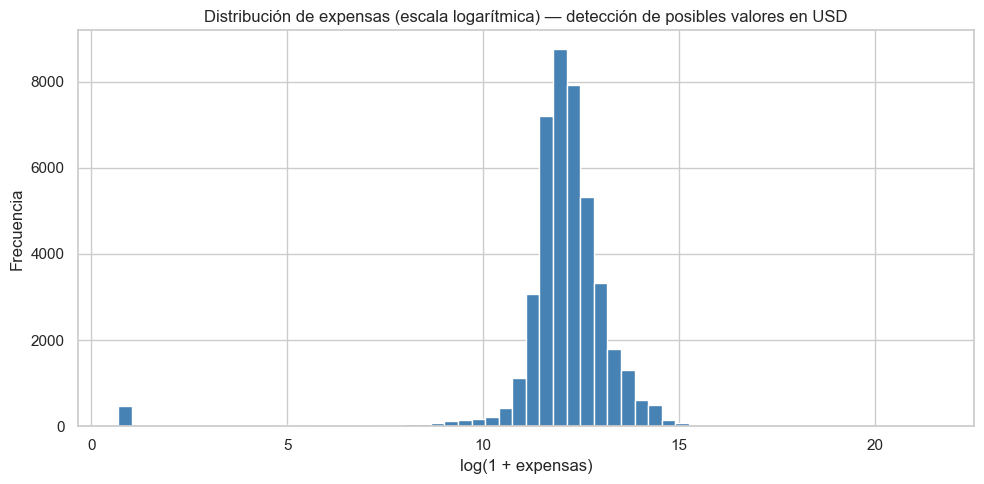

In [33]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df_final['expensas'].dropna()
ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")
plt.tight_layout()
plt.show()

Vemos que hay un grupo de valores con expensas muy bajas, entonces usamos el grafico del codo para buscar donde esta el corte:

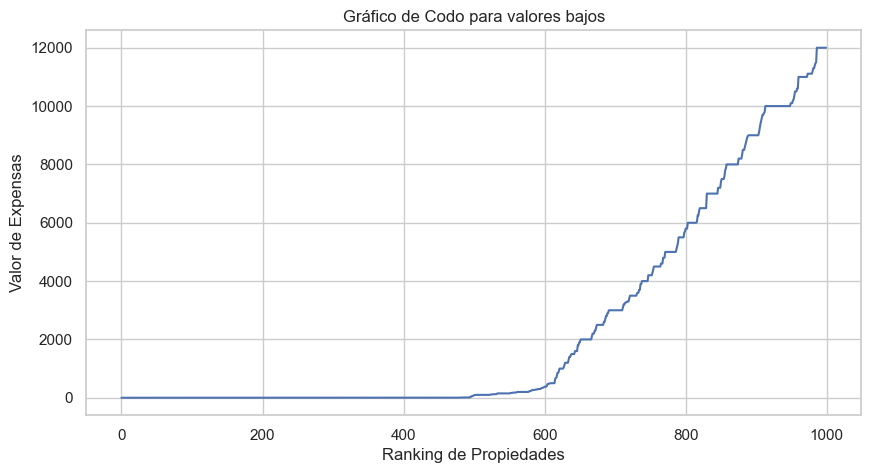

In [34]:
# Ordenamos los valores de menor a mayor
expensas_ordenadas = df_final['expensas'].dropna().sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(expensas_ordenadas[:1000]) # Miramos los primeros 500 registros más bajos
plt.ylabel("Valor de Expensas")
plt.xlabel("Ranking de Propiedades")
plt.title("Gráfico de Codo para valores bajos")
plt.show()

En este grafico vemos que hasta la propiedad número 500 aproximadamente, el valor es 0, por lo que son departamentos sin expensas. Despues, entre la propiedad 500 y la 600, la línea empieza a despegarse pero muy lentamente, son valores insignificantes (1, 10, 100 pesos). Vamos a considerar estos valores, como numeros que la gente puso para representar que no hay expensas.

Entonces, el verdadero "salto" de mercado, donde la pendiente se vuelve empinada y constante, empieza alrededor de la propiedad 600, que coincide con valores superiores a los $2.000 - $3.000. Ahí es donde pondremos nuestro umbral.

In [35]:
import numpy as np

# Definimos el cutoff basado en el gráfico de codo
umbral_basura = 100
umbral_minimo_mercado = 4000 

# Creamos una columna nueva para no perder la original por si queremos comparar
df_final['expensas_ok'] = df_final['expensas']

# Aplicamos la lógica que dedujimos del gráfico
df_final.loc[df_final['expensas'] < umbral_basura, 'expensas_ok'] = 0
mask_error = (df_final['expensas'] >= umbral_basura) & (df_final['expensas'] < umbral_minimo_mercado)
df_final.loc[mask_error, 'expensas_ok'] = np.nan

# Calculamos estadisticas sobre la columna limpia:
resumen_expensas_ok = df_final.groupby('operacion')['expensas_ok'].agg(
    count='count',         
    media='mean',          # La media debería subir
    mediana='median',      # La mediana va a ser más realista
    p5=lambda x: x.quantile(0.05)
).round(0)

print("Resumen de expensas LIMPIAS:")
print(resumen_expensas_ok)

# sobre la columna original:
resumen_expensas_og = df_final.groupby('operacion')['expensas'].agg(
    count='count',         
    media='mean',          # La media debería subir
    mediana='median',      # La mediana va a ser más realista
    p5=lambda x: x.quantile(0.05)
).round(0)

print("\nResumen de expensas ORIGINALES:")
print(resumen_expensas_og)

# Verificamos si quedan sospechosos despues de la limpieza
sospechosos_nuevos = df_final[
    (df_final['expensas_ok'] > 0) & 
    (df_final['expensas_ok'] < umbral_minimo_mercado)
]['expensas_ok']

print(f"\nSospechosos en columna limpia: {len(sospechosos_nuevos)}")

# 1. Cuántos eran menores a 100 (convertidos a 0)
cant_a_cero = len(df_final[(df_final['expensas'] < 100)])

# 2. Cuántos eran "ruido" (convertidos a NaN)
# Estos son los que el análisis de codo nos dijo que eran errores
cant_a_nan = len(df_final[(df_final['expensas'] >= 100) & (df_final['expensas'] < 4000)])

# 3. Resumen total
total_registros = len(df_final)

print(f"\n--- Auditoría de Limpieza de Expensas ---")
print(f"Total de registros analizados: {total_registros}")
print(f"Registros llevados a 0 (sin expensas): {cant_a_cero}")
print(f"Registros anulados (ruido/errores): {cant_a_nan}")
print(f"Total de datos modificados: {cant_a_cero + cant_a_nan}")
print(f"Porcentaje de datos 'sucios' eliminados: {((cant_a_nan / total_registros) * 100):.2f}%")

# Reemplazamos expensas por expensas_ok:
df_final = df_final.drop(columns=['expensas']).rename(columns={'expensas_ok': 'expensas'})

Resumen de expensas LIMPIAS:
                   count     media   mediana       p5
operacion                                            
alquiler           17902  525461.0  180000.0  75000.0
alquiler_temporal   2972  205321.0  154124.0  15000.0
venta              21990  300591.0  190000.0  45500.0

Resumen de expensas ORIGINALES:
                   count     media   mediana       p5
operacion                                            
alquiler           17977  523271.0  180000.0  74000.0
alquiler_temporal   3009  202799.0  150000.0    540.0
venta              22113  298931.0  187200.0  40000.0

Sospechosos en columna limpia: 0

--- Auditoría de Limpieza de Expensas ---
Total de registros analizados: 62937
Registros llevados a 0 (sin expensas): 503
Registros anulados (ruido/errores): 235
Total de datos modificados: 738
Porcentaje de datos 'sucios' eliminados: 0.37%


Revisamos como quedo:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


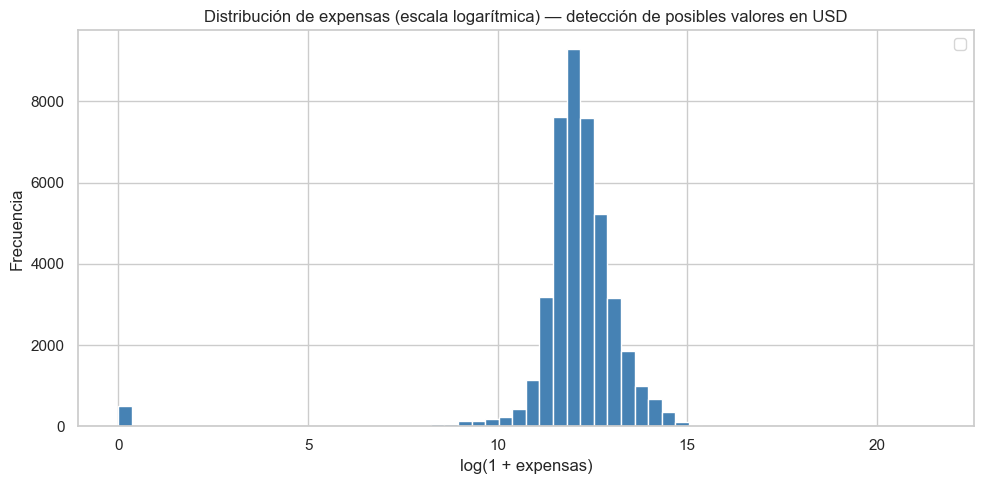

In [36]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df_final['expensas'].dropna()

ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")
ax.legend()

plt.tight_layout()
plt.show()

# 7. Valores faltantes:

## Inspeccionamos:

Vemos como se estructuran los valores faltantes que tenemos:

In [37]:
missing_info = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

print("Variables con datos faltantes:")
missing_summary = pd.DataFrame({
    'Variable': missing_info.index,
    'Datos_Faltantes': missing_info.values,
    'Porcentaje': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Datos_Faltantes'] > 0]
print(missing_summary.to_string(index=False))

Variables con datos faltantes:
       Variable  Datos_Faltantes  Porcentaje
         precio             1494    2.373802
          calle             5370    8.532342
         altura             5370    8.532342
           piso            49314   78.354545
       detalles              220    0.349556
    descripción              293    0.465545
 barrio_oficial                3    0.004767
      ambientes            30464   48.403960
antiguedad_años            37387   59.403848
          baños            21414   34.024501
    calefaccion            50844   80.785547
    cocina_tipo            42540   67.591401
    dormitorios            13624   21.647044
       m2_total             2436    3.870537
    orientacion            30324   48.181515
 tiene_expensas              293    0.465545
       expensas            20073   31.893799


Muchos de los valores faltante provienen de las columnas que agregamos en el parse, tanto de detalle como de descripcion. Vemos los valores faltantes, separando por sitio: tal vez los datos de zonaprop tienen detalles distintos a los de argenprop.

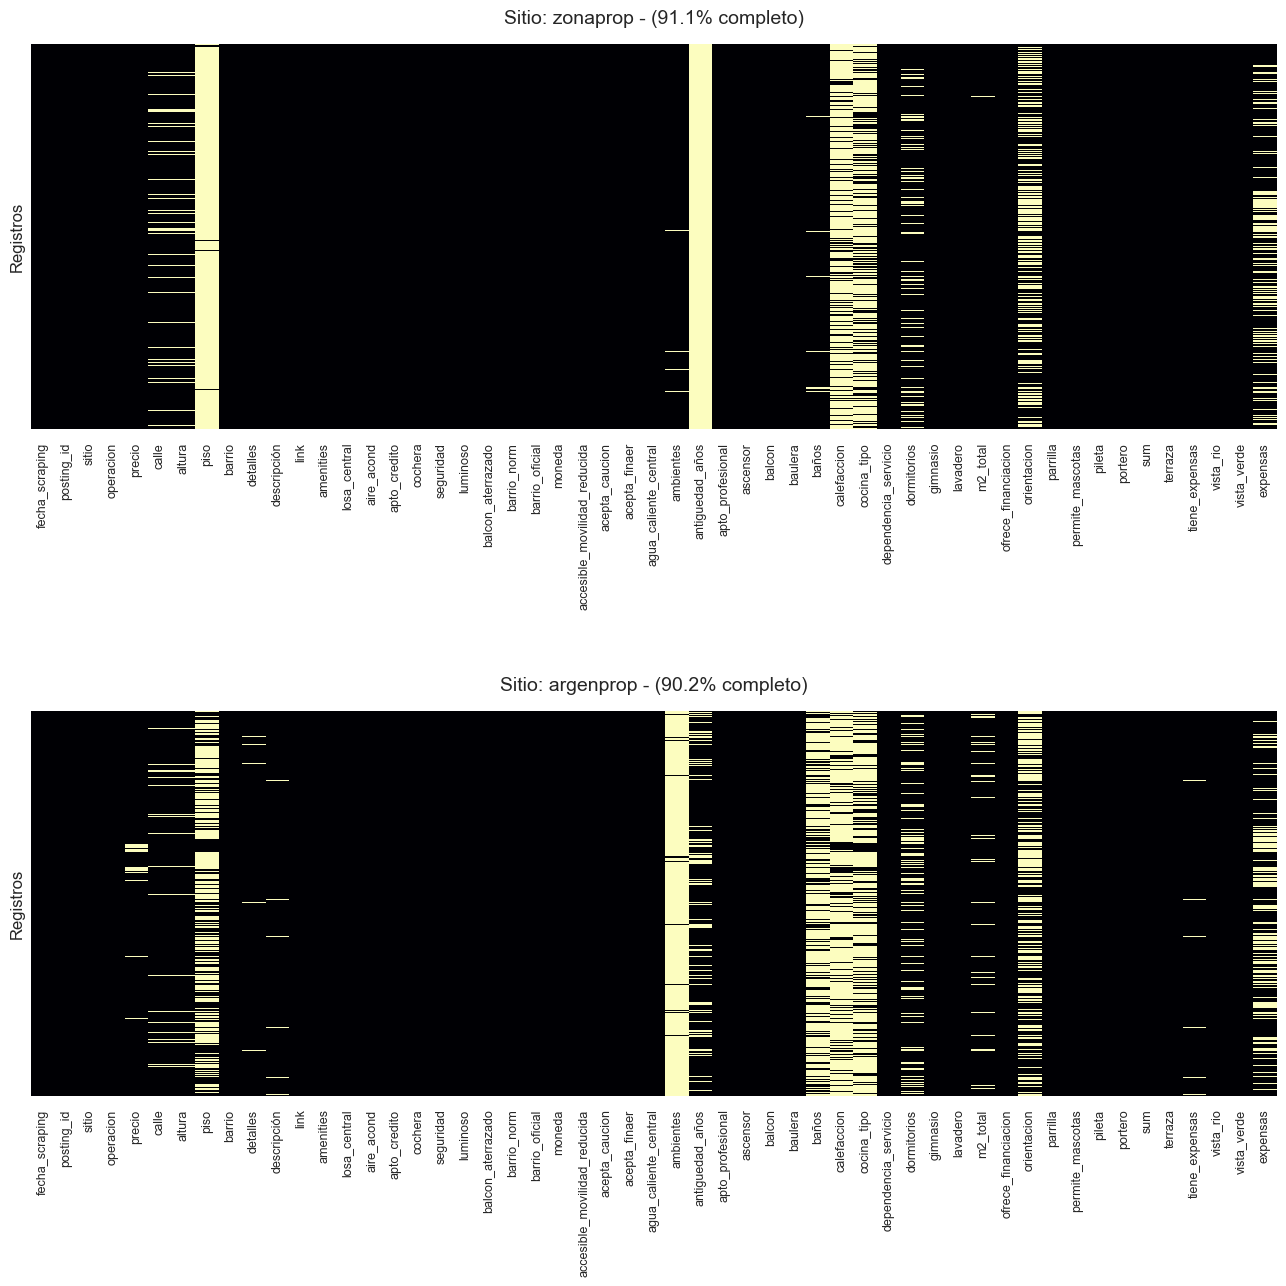

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sitios = df_final['sitio'].unique()
n_sitios = len(sitios)

# Aumentamos un poco el ancho (14) para que las columnas respiren
fig, axes = plt.subplots(n_sitios, 1, figsize=(14, 7 * n_sitios))

if n_sitios == 1:
    axes = [axes]

for i, sitio in enumerate(sitios):
    df_sitio = df_final[df_final['sitio'] == sitio]
    
    # cmap='magma' suele resaltar mejor los nulos (amarillo sobre negro/morado)
    sns.heatmap(df_sitio.isnull(), cbar=False, ax=axes[i], yticklabels=False, cmap='magma')
    
    axes[i].set_xticklabels(axes[i].get_xticklabels(), 
                            rotation=90, 
                            horizontalalignment='center', 
                            fontsize=9)
    
    # Forzamos que se muestren TODAS las etiquetas
    axes[i].set_xticks(np.arange(len(df_sitio.columns)) + 0.5)
    
    total_celdas = df_sitio.size
    nulos = df_sitio.isnull().sum().sum()
    completitud = 100 * (1 - nulos/total_celdas)
    
    axes[i].set_title(f'Sitio: {sitio} - ({completitud:.1f}% completo)', fontsize=14, pad=15)
    axes[i].set_ylabel('Registros')

plt.tight_layout(pad=4.0)
plt.show()

Efectivamente, podemos ver que variables como ambientes y baños estan practicamente completas en zonaprop, y practicamente vacias en argenprop; antigüedad_años esta vacia en zonaprop, pero mucho mas completa en argenprop. Vemos como se compone detalles:

In [39]:
df_final[df_final['sitio']=='zonaprop']['detalles']

0                  60 m² tot. 2 amb. 1 dorm. 1 baño
1        114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.
2        121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.
3                  66 m² tot. 2 amb. 1 dorm. 1 baño
4        117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.
                            ...                    
31745           150 m² tot. 2 dorm. 2 baños 1 coch.
31746              51 m² tot. 2 amb. 1 dorm. 1 baño
31747              77 m² tot. 3 amb. 2 dorm. 1 baño
31748    169 m² tot. 4 amb. 3 dorm. 2 baños 2 coch.
31749             80 m² tot. 3 amb. 2 dorm. 2 baños
Name: detalles, Length: 31750, dtype: object

In [40]:
df_final[df_final['sitio']=='argenprop']['detalles']

31750         47 m² cubie. Monoam. Bueno
31751       80 m² cubie. 2 dorm. 15 años
31752      100 m² cubie. 2 dorm. 40 años
31753        27 m² cubie. 1 baño Monoam.
31754       34 m² cubie. 1 dorm. 80 años
                      ...               
62932       63 m² cubie. 2 dorm. 30 años
62933        25 m² cubie. 40 años 1 baño
62934    60 m² cubie. 1 dorm. A Estrenar
62935       65 m² cubie. 2 dorm. 15 años
62936       62 m² cubie. 3 dorm. 50 años
Name: detalles, Length: 31187, dtype: object

Podemos ver reflejadas esas diferencias.

Igualmente, tambien hay variables a las que le faltan muchos valores en ambos, que pueden faltar desde el scraper (como calle, altura y piso), o del parse de descripcion (como calefaccion, cocina_tipo y orientación).

Entonces, teniendo esto cuenta, vamos a utilizar distintas tecnicas para tratar los valores faltantes.

## Tratamos los valores faltantes

### Expensas:

Para tratar las expensas, vamos a utilizar la variable tiene_expensas, que construimos a partir del parse de descripción. Si el valor es faltante, y tiene_expensas es 0, imputamos un 0; pero si tiene_expensas es 1, utilizamos el precio y el barrio para imputar el valor.

In [41]:
# 1. Creamos segmentos de precio (deciles) para que la imputación sea lógica
# Usamos qcut para que cada grupo tenga la misma cantidad de deptos
df_final['segmento_precio'] = pd.qcut(df_final['precio'], q=10, labels=False, duplicates='drop')

# 2. Aplicamos la imputación condicional de expensas
# Primero: Si 'tiene_expensas' es 0, el valor es 0
df_final.loc[df_final['tiene_expensas'] == 0, 'expensas'] = 0

# Segundo: Para los que 'tiene_expensas' es 1 pero el valor es NaN
# Imputamos por la mediana de su BARRIO y su SEGMENTO DE PRECIO
df_final['expensas'] = df_final.groupby(['barrio', 'segmento_precio'])['expensas'].transform(
    lambda x: x.fillna(x.median())
)

# Tercero: Si aún quedan nulos (barrios con pocos datos en ese segmento), 
# usamos solo el segmento de precio a nivel general
df_final['expensas'] = df_final.groupby('segmento_precio')['expensas'].transform(
    lambda x: x.fillna(x.median())
)

# Si todavia quedan nulos, usamos la mediana general de todo el dataset para que NO quede ni un solo nulo
df_final['expensas'].fillna(df_final['expensas'].median(), inplace=True)

# Borramos la columna auxiliar para que no ensucie el modelo
df_final.drop(columns=['segmento_precio'], inplace=True)

### Ambientes, baños, dormitorio, antigüedad:

Como estas variables se encuentran mas que nada en uno de los sitios, usamos los datos del otro sitio como base, para imputar los valores segun los m2 del departamento

In [42]:
# 1. Crear rangos de m2 para que la imputación sea coherente
df_final['m2_bin'] = pd.qcut(df_final['m2_total'], q=10, duplicates='drop')

# 2. Lista de variables estructurales a salvar
vars_estructurales = ['ambientes', 'baños', 'dormitorios', 'antiguedad_años']

for col in vars_estructurales:
    # Imputamos por la mediana del Barrio Y el Rango de M2
    df_final[col] = df_final.groupby(['barrio', 'm2_bin'])[col].transform(lambda x: x.fillna(x.median()))
    
    # Si todavía quedan nulos (porque ese bin en ese barrio está vacío), usamos solo el bin
    df_final[col] = df_final.groupby('m2_bin')[col].transform(lambda x: x.fillna(x.median()))
    
    # Si todavia quedan nulos, usamos la mediana general de todo el dataset para que NO quede ni un solo nulo
    df_final[col].fillna(df_final[col].median(), inplace=True)


# 4. Limpieza final de columnas descartadas
df_final.drop(columns='m2_bin', inplace=True, errors='ignore')

### Otras:

Rescatamos si la calle está sobre un avenida.

In [43]:
avenidas_conocidas = ['avenida', 'av.', 'av ', 'diagonal']
df_final['sobre_avenida'] = df_final['calle'].str.lower().str.contains(
    '|'.join(avenidas_conocidas), na=False
).astype(int)


Finalmente, las que tienen un numero demasiado alto de valores faltantes, y no son pertinentes para nuestro analisis, las eliminamos:

In [44]:
cols_descarte = ['piso', 'calefaccion', 'cocina_tipo', 'orientacion']
df_final.drop(columns=cols_descarte, inplace=True, errors='ignore')

## Revisamos como quedo:

In [45]:
missing_info = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

print("Variables con datos faltantes:")
missing_summary = pd.DataFrame({
    'Variable': missing_info.index,
    'Datos_Faltantes': missing_info.values,
    'Porcentaje': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Datos_Faltantes'] > 0]
print(missing_summary.to_string(index=False))

Variables con datos faltantes:
      Variable  Datos_Faltantes  Porcentaje
        precio             1494    2.373802
         calle             5370    8.532342
        altura             5370    8.532342
      detalles              220    0.349556
   descripción              293    0.465545
barrio_oficial                3    0.004767
      m2_total             2436    3.870537
tiene_expensas              293    0.465545


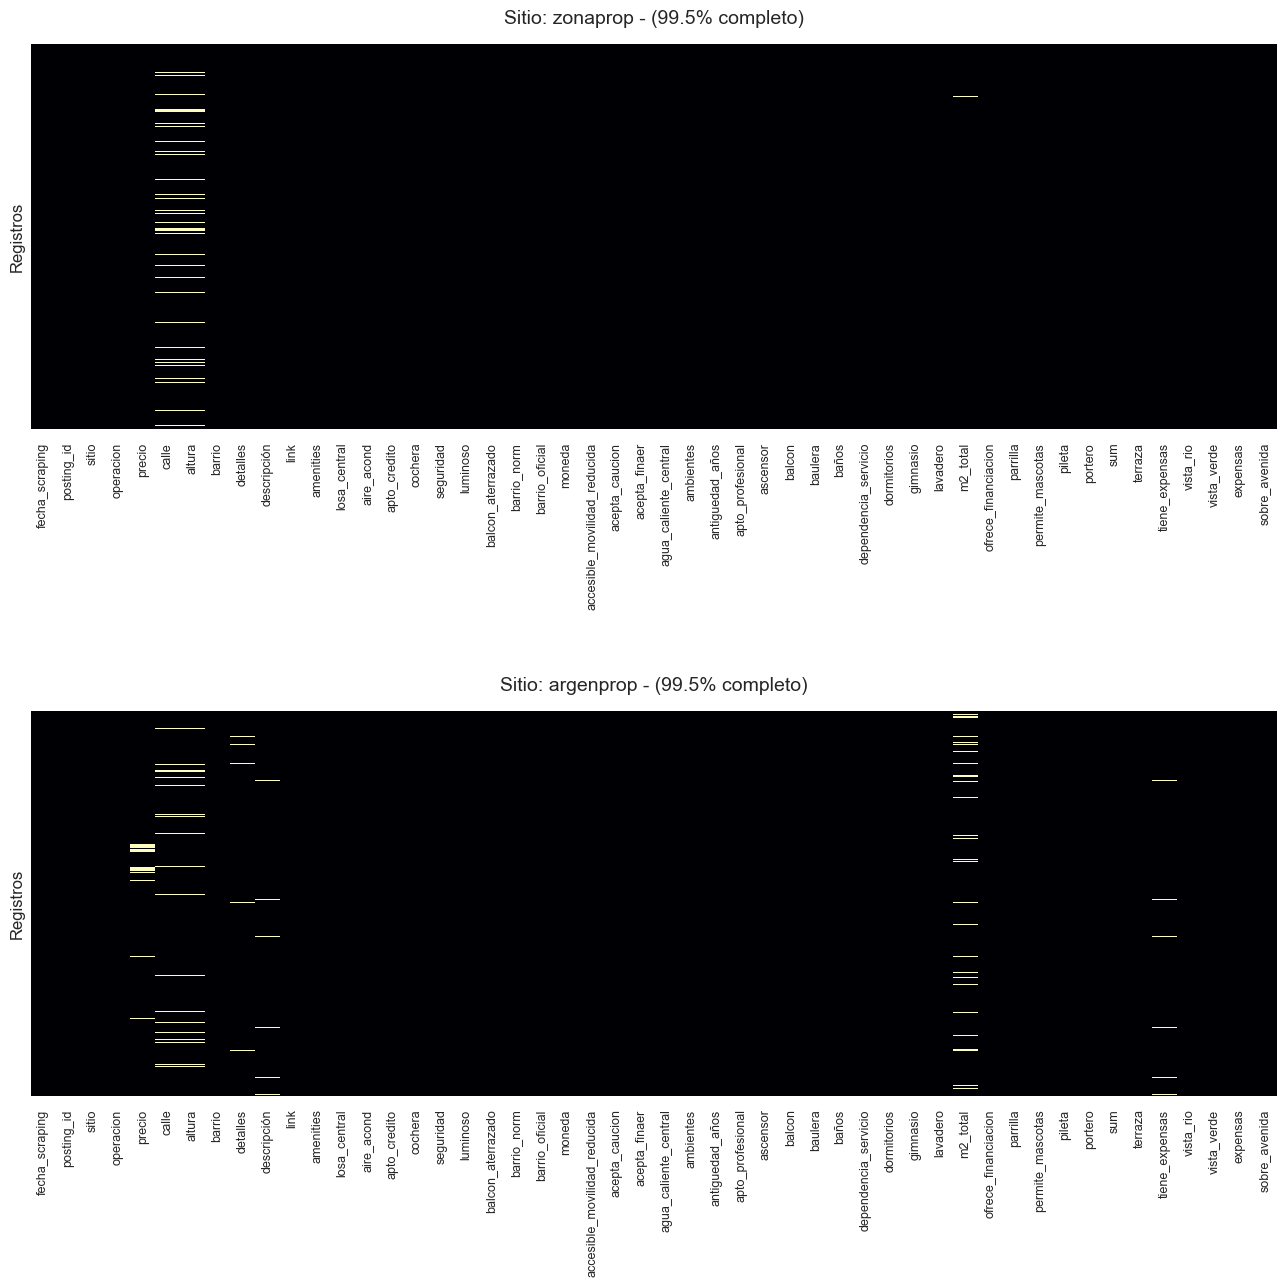

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sitios = df_final['sitio'].unique()
n_sitios = len(sitios)

fig, axes = plt.subplots(n_sitios, 1, figsize=(14, 7 * n_sitios))

if n_sitios == 1:
    axes = [axes]

for i, sitio in enumerate(sitios):
    df_sitio = df_final[df_final['sitio'] == sitio]
    
    sns.heatmap(df_sitio.isnull(), cbar=False, ax=axes[i], yticklabels=False, cmap='magma')
    
    axes[i].set_xticklabels(axes[i].get_xticklabels(), 
                            rotation=90, 
                            horizontalalignment='center', 
                            fontsize=9)
    
    axes[i].set_xticks(np.arange(len(df_sitio.columns)) + 0.5)
    
    total_celdas = df_sitio.size
    nulos = df_sitio.isnull().sum().sum()
    completitud = 100 * (1 - nulos/total_celdas)
    
    axes[i].set_title(f'Sitio: {sitio} - ({completitud:.1f}% completo)', fontsize=14, pad=15)
    axes[i].set_ylabel('Registros')

plt.tight_layout(pad=4.0)
plt.show()

Finalmente, borramos los registros de lo pocos datos faltantes que quedan, ya que son muy pocos, y no vale la pena imputarlos: los de precio y m2 es importante que sean reales; y los de detalle, descripcion son imposibles (e innecesarios) de completar.

No eliminamos calle y altura porque pueden ser utiles posteriormente para realizar un analisis geoespacial

In [47]:
# 1. Eliminamos registros sin las variables fundamentales (Precio y Metros)
# Es mejor perder un 4% de datos que tener datos inventados en el core
df_final.dropna(subset=['precio', 'm2_total', 'barrio_oficial'], inplace=True)

# 2. Eliminamos registros sin descripción o detalles
# Sin esto no pudimos haber hecho el feature engineering correctamente
df_final.dropna(subset=['descripción', 'detalles'], inplace=True)

# 3. Verificamos que no quede NADA nulo en estas columnas
print("Nulos después de la limpieza final:")
print(df_final.isnull().sum())

Nulos después de la limpieza final:
fecha_scraping                     0
posting_id                         0
sitio                              0
operacion                          0
precio                             0
calle                           5225
altura                          5225
barrio                             0
detalles                           0
descripción                        0
link                               0
amenities                          0
losa_central                       0
aire_acond                         0
apto_credito                       0
cochera                            0
seguridad                          0
luminoso                           0
balcon_aterrazado                  0
barrio_norm                        0
barrio_oficial                     0
moneda                             0
accesible_movilidad_reducida       0
acepta_caucion                     0
acepta_finaer                      0
agua_caliente_central              0
am

# 8. Tratamiento de Outliers (con precio_por_m2):

## Paso 1 - Imports

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 50)

## Paso 2 - Calcular precio_por_m²

Usamos precio_por_m² como KPI central en lugar del precio total porque permite comparar propiedades de distintos tamaños dentro del mismo barrio. Sin esta normalización, un PH de 200m² siempre va a parecer outlier por precio total aunque sea perfectamente normal por m².

Filtramos antes de calcular para no propagar NaN ni divisiones inválidas.

Revisamos valores muy bajos de m², que puedan haber sido cargados mal, para saber donde cortar:

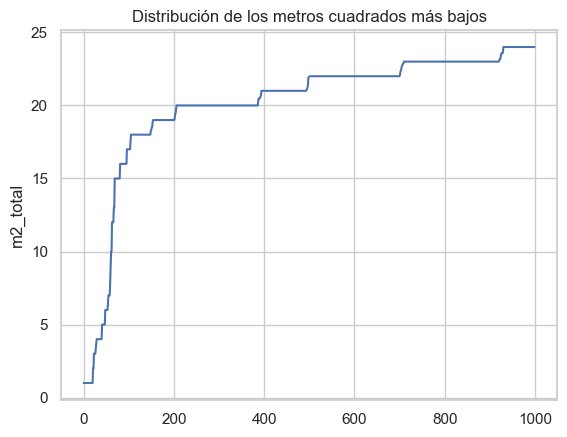

In [49]:
df_prueba = df_final.copy()

# Graficamos el "codo" de los metros cuadrados
plt.plot(df_prueba['m2_total'].sort_values().reset_index(drop=True)[:1000])
plt.title("Distribución de los metros cuadrados más bajos")
plt.ylabel("m2_total")
plt.show()

Podemos ver que por debajo de 15 hay algunos departamento, aunque no tienen sentido lógico. A partir de 15, aumenta claramente la cantidad de departamentos, por lo que probablemente los anteriores sean un error de carga. Por lo que los filtramos antes de calcular precio_por_m2:

In [50]:
mask_m2 = (
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 15) & # filtramos los de menos de 15m²
    df_final['precio'].notna() &
    (df_final['precio'] > 0)
)

df_final['precio_por_m2'] = np.nan
df_final.loc[mask_m2, 'precio_por_m2'] = (
    df_final.loc[mask_m2, 'precio'] / df_final.loc[mask_m2, 'm2_total']
)

print(f"Con precio_por_m2: {mask_m2.sum():,} de {len(df_final):,} ({mask_m2.mean()*100:.1f}%)")

# Nos quedamos solo con registros que tienen precio_por_m2 calculado
df_final = df_final[df_final['precio_por_m2'].notna()].copy()
print(f"Registros con precio_por_m2 válido: {len(df_final):,}")

Con precio_por_m2: 58,742 de 58,823 (99.9%)
Registros con precio_por_m2 válido: 58,742


Nos quedamos con los que se puede calcular precio_por_m2, ya que es una metrica sumamente importante.

## Paso 3 - Deduplicar scraping

Al scrapear, el mismo aviso podria aparecer más de una vez. Deduplicamos por posting_id + sitio, no por características de la propiedad (barrio, precio, m²), porque dos inmuebles distintos pueden coincidir en esas columnas y no son duplicados.

In [51]:
n_antes = len(df_final)
df_final = df_final.drop_duplicates(subset=['posting_id', 'sitio'], keep='first').copy()

n_eliminados = n_antes - len(df_final)
print(f"Duplicados de scraping eliminados: {n_eliminados:,} ({n_eliminados/n_antes*100:.1f}%)")
print(f"Registros restantes: {len(df_final):,}")

assert df_final.duplicated(subset=['posting_id', 'sitio']).sum() == 0, "Todavía hay duplicados!"

Duplicados de scraping eliminados: 5,016 (8.5%)
Registros restantes: 53,726


Eliminamos el 8.5% de los registros duplicados

## Paso 4 - Corrección de errores de moneda

Existe una dependencia circular entre detección de moneda y análisis de outliers: si un precio en USD fue clasificado como ARS por error, va a aparecer como valor extremadamente bajo dentro del segmento ARS. Si no lo corregimos antes, puede sobrevivir los filtros de outliers cuando en realidad es un error de clasificación.

Primero graficamos la distribución de precios ARS para elegir los umbrales con criterio visual, luego reclasificamos.

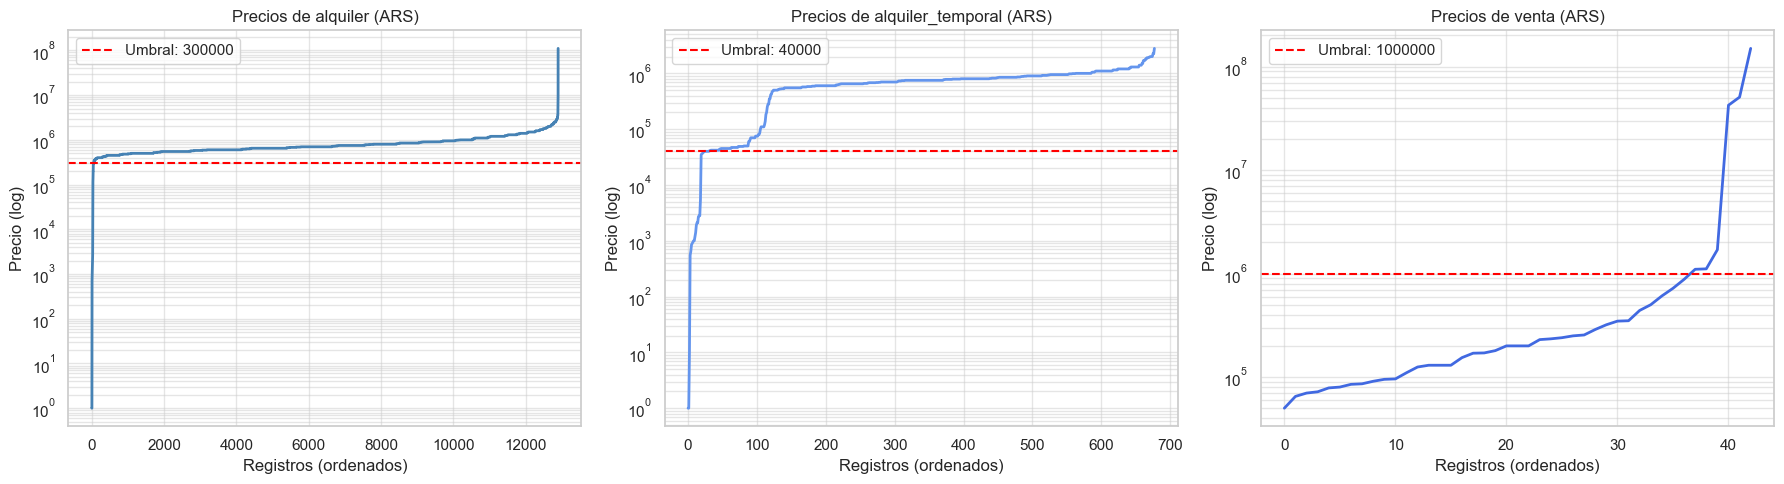

In [52]:
import matplotlib.pyplot as plt

ops = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 300000, 'alquiler_temporal': 40000, 'venta': 1000000}
colores = ['steelblue', 'cornflowerblue', 'royalblue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, op, color in zip(axes, ops, colores):
    subset = df_final[
        (df_final['moneda'] == 'ars') & (df_final['operacion'] == op)
    ]['precio'].dropna().sort_values().reset_index(drop=True)
    
    if not subset.empty:
        ax.plot(subset.values, color=color, linewidth=2)
        umb = umbrales[op]
        ax.axhline(y=umb, color='red', linestyle='--', label=f'Umbral: {umb}')
        
        ax.set_title(f'Precios de {op} (ARS)')
        ax.set_yscale('log')
        ax.set_ylabel('Precio (log)')
        ax.set_xlabel('Registros (ordenados)')
        ax.legend()
        ax.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

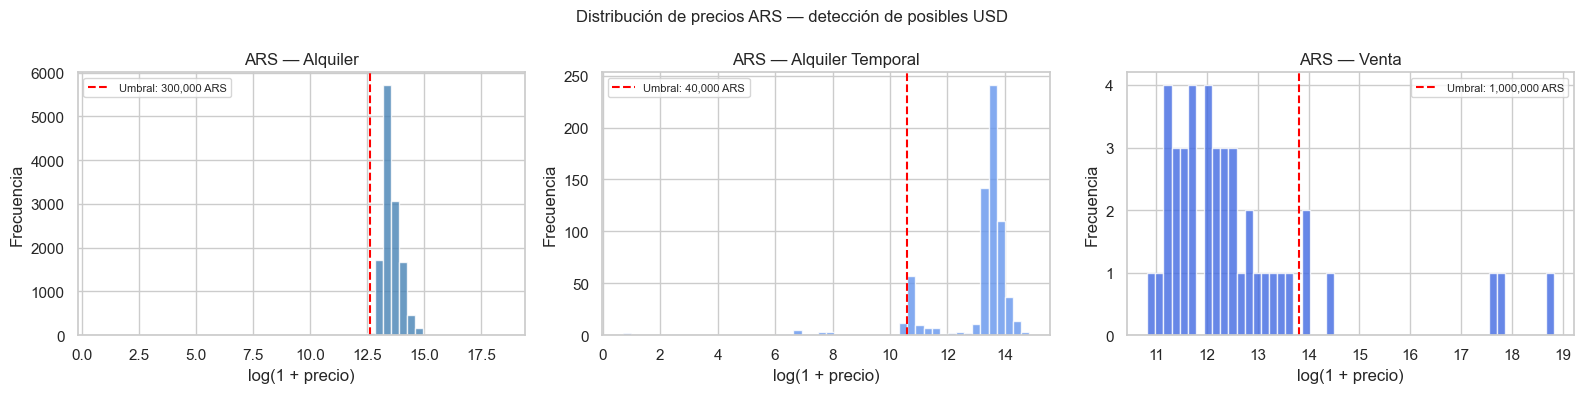

Registros ARS por debajo del umbral (candidatos a reclasificar):
  alquiler: 42 registros con precio < 300,000 ARS
  alquiler_temporal: 23 registros con precio < 40,000 ARS
  venta: 37 registros con precio < 1,000,000 ARS


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de precios ARS — detección de posibles USD', fontsize=12)

ops      = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 300_000, 'alquiler_temporal': 40_000, 'venta': 1_000_000}
#umbrales = {'alquiler': 120_000, 'alquiler_temporal': 100_000, 'venta': 100_000}
colores  = ['steelblue', 'cornflowerblue', 'royalblue']

for ax, op, color in zip(axes, ops, colores):
    subset = df_final[
        (df_final['moneda'] == 'ars') & (df_final['operacion'] == op)
    ]['precio'].dropna()

    ax.hist(np.log1p(subset), bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(
        np.log1p(umbrales[op]),
        color='red', linestyle='--',
        label=f'Umbral: {umbrales[op]:,} ARS'
    )
    ax.set_title(f"ARS — {op.replace('_', ' ').title()}")
    ax.set_xlabel('log(1 + precio)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Registros ARS por debajo del umbral (candidatos a reclasificar):")
for op, umbral in umbrales.items():
    n = (
        (df_final['moneda'] == 'ars') &
        (df_final['operacion'] == op) &
        (df_final['precio'] < umbral)
    ).sum()
    print(f"  {op}: {n} registros con precio < {umbral:,} ARS")

Un alquiler ARS < 300.000 pesos en 2026 es imposible → probablemente USD

Un alquiler temporal ARS < 40.000 pesos en 2026 es imposible → probablemente USD

Una venta ARS < 1.000.000 pesos en 2026 es imposible → probablemente USD

Entonces:

In [54]:
UMBRALES_IMPOSIBLES_ARS = {
    'alquiler':           300_000,
    'alquiler_temporal':  40_000,
    'venta':             1_000_000,
}

n_reclasificados = 0
for op, umbral in UMBRALES_IMPOSIBLES_ARS.items():
    mask = (
        (df_final['moneda'] == 'ars') &
        (df_final['operacion'] == op) &
        (df_final['precio'] < umbral)
    )
    n_reclasificados += mask.sum()
    df_final.loc[mask, 'moneda'] = 'usd'
    print(f"  Reclasificados '{op}': {mask.sum()} registros")

print(f"\nTotal reclasificados ARS → USD: {n_reclasificados}")

  Reclasificados 'alquiler': 42 registros
  Reclasificados 'alquiler_temporal': 23 registros
  Reclasificados 'venta': 37 registros

Total reclasificados ARS → USD: 102


Ahora, probamos algo similar, pero en los alquileres que tienen valores en dolares demasiado grandes, que probablemente sean pesos:

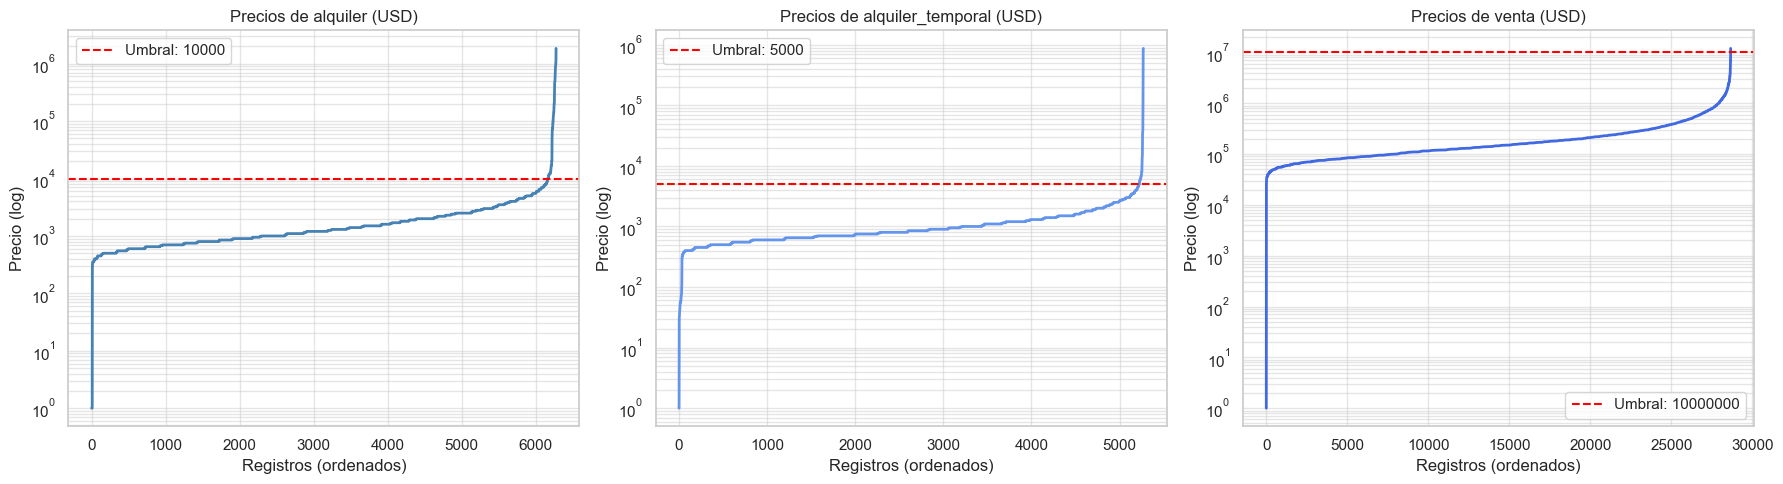

Registros USD por arriba del umbral (candidatos a reclasificar):
  alquiler: 104 registros con precio > 10,000 USD
  alquiler_temporal: 45 registros con precio > 5,000 USD
  venta: 1 registros con precio > 10,000,000 USD


In [55]:
import matplotlib.pyplot as plt

ops = ['alquiler', 'alquiler_temporal', 'venta']
# Definimos los umbrales en un diccionario para claridad
umbrales = {'alquiler': 10000, 'alquiler_temporal': 5000, 'venta': 10000000}
colores = ['steelblue', 'cornflowerblue', 'royalblue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, op, color in zip(axes, ops, colores):
    # IMPORTANTE: .sort_values() para ver el "codo"
    subset = df_final[
        (df_final['moneda'] == 'usd') & (df_final['operacion'] == op)
    ]['precio'].dropna().sort_values().reset_index(drop=True)
    
    if not subset.empty:
        ax.plot(subset.values, color=color, linewidth=2)
        umb = umbrales[op]
        ax.axhline(y=umb, color='red', linestyle='--', label=f'Umbral: {umb}')
        
        ax.set_title(f'Precios de {op} (USD)')
        ax.set_yscale('log')
        ax.set_ylabel('Precio (log)')
        ax.set_xlabel('Registros (ordenados)')
        ax.legend()
        ax.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

print("Registros USD por arriba del umbral (candidatos a reclasificar):")
for op, umbral in umbrales.items():
    n = (
        (df_final['moneda'] == 'usd') &
        (df_final['operacion'] == op) &
        (df_final['precio'] > umbral)
    ).sum()
    print(f"  {op}: {n} registros con precio > {umbral:,} USD")

Vemos que a partir de 10000, hay unos pocos registros que tienen valores demasiados altos, para ser dolares. Por lo cual definimos este como nuestro umbral

In [56]:
UMBRALES_IMPOSIBLES_USD = {
    'alquiler':           10_000,
    'alquiler_temporal':  5_000,
    'venta':             10_000_000,
}

n_reclasificados = 0
for op, umbral in UMBRALES_IMPOSIBLES_USD.items():
    mask = (
        (df_final['moneda'] == 'usd') &
        (df_final['operacion'] == op) &
        (df_final['precio'] > umbral)
    )
    n_reclasificados += mask.sum()
    df_final.loc[mask, 'moneda'] = 'ars'
    print(f"  Reclasificados '{op}': {mask.sum()} registros")

print(f"\nTotal reclasificados USD → ARS: {n_reclasificados}")

  Reclasificados 'alquiler': 104 registros
  Reclasificados 'alquiler_temporal': 45 registros
  Reclasificados 'venta': 1 registros

Total reclasificados USD → ARS: 150


## Paso 5 - Filtros absolutos

Eliminamos valores que son imposibles en cualquier contexto del mercado. Estos errores contaminarían el cálculo de percentiles si los dejamos adentro, por eso se aplican antes del paso de Winsorización.

La diferencia con el paso anterior es que allá corregíamos la moneda; acá directamente eliminamos registros que no tienen sentido en ningún segmento.

In [57]:
PISO_USD_ALQUILER = 5        # USD/m² — imposible en cualquier barrio de CABA
PISO_USD_VENTA    = 400      # USD/m² — por debajo → casi seguro error de moneda
PISO_ARS_ALQUILER = 3_000    # ARS/m² — mínimo razonable post-corrección
TECHO_USD_M2      = 25_000   # USD/m² - por encima → error de tipeo

mask_error = (
    # ventas USD con precio ridículo
    ((df_final['operacion'] == 'venta') &
     (df_final['moneda'] == 'usd') &
     (df_final['precio_por_m2'] < PISO_USD_VENTA))
    |
    # alquileres USD imposibles
    ((df_final['operacion'].isin(['alquiler', 'alquiler_temporal'])) &
     (df_final['moneda'] == 'usd') &
     (df_final['precio_por_m2'] < PISO_USD_ALQUILER))
    |
    # alquileres ARS imposibles
    ((df_final['operacion'].isin(['alquiler', 'alquiler_temporal'])) &
     (df_final['moneda'] == 'ars') &
     (df_final['precio_por_m2'] < PISO_ARS_ALQUILER))
    |
    # techo absoluto global
    (df_final['precio_por_m2'] > TECHO_USD_M2)
)

print(f"Eliminados por filtros absolutos: {mask_error.sum():,}")
df_final = df_final[~mask_error].copy()
print(f"Registros restantes: {len(df_final):,}")

Eliminados por filtros absolutos: 974
Registros restantes: 52,752


## Paso 6 - Percentiles adaptativos + Winsorización

Para los valores extremos que sí existen en el mercado (propiedades de lujo, PHs grandes), Winsorizamos en lugar de eliminar: reemplazamos el valor extremo por el límite del percentil, conservando el registro con todas sus features para el modelo.

El percentil es adaptativo por segmento: calculamos P1-P99 por operacion + moneda + barrio. Si el barrio tiene menos de 30 registros, usamos operacion + moneda como fallback para que el percentil sea estadísticamente válido.

Esto es importante porque Villa Lugano y Puerto Madero tienen rangos de precios completamente distintos: un percentil global trataría como outlier propiedades perfectamente normales en cada uno.

In [58]:
N_MIN         = 30     # mínimo de registros para usar percentil por barrio
SEG_FINO      = ['operacion', 'moneda', 'barrio_oficial']
SEG_GRUESO    = ['operacion', 'moneda']
Q_LOW, Q_HIGH = 0.01, 0.99


def calcular_percentiles_adaptativos(df, col, seg_fino, seg_grueso, q_low, q_high, n_min):
    """Calcula percentiles por segmento fino; usa segmento grueso si n < n_min."""
    df = df.copy()

    stats_fino = (
        df.groupby(seg_fino)[col]
        .agg(
            n      = 'count',
            p_low  = lambda x: x.quantile(q_low),
            p_high = lambda x: x.quantile(q_high)
        )
        .reset_index()
    )
    stats_grueso = (
        df.groupby(seg_grueso)[col]
        .agg(
            p_low_fb  = lambda x: x.quantile(q_low),
            p_high_fb = lambda x: x.quantile(q_high)
        )
        .reset_index()
    )

    df = df.merge(stats_fino,   on=seg_fino,   how='left')
    df = df.merge(stats_grueso, on=seg_grueso, how='left')

    df['p_low']  = np.where(df['n'] >= n_min, df['p_low'],  df['p_low_fb'])
    df['p_high'] = np.where(df['n'] >= n_min, df['p_high'], df['p_high_fb'])

    return df.drop(columns=['n', 'p_low_fb', 'p_high_fb'])


df_final = calcular_percentiles_adaptativos(
    df_final, 'precio_por_m2',
    SEG_FINO, SEG_GRUESO,
    Q_LOW, Q_HIGH, N_MIN
)

# Guardar el valor original para referencia y para el paso siguiente
df_final['precio_por_m2_original'] = df_final['precio_por_m2'].copy()

# Winsorizar: reemplazar por el límite en lugar de eliminar
mask_sup = df_final['precio_por_m2'] > df_final['p_high']
mask_inf = df_final['precio_por_m2'] < df_final['p_low']

df_final.loc[mask_sup, 'precio_por_m2'] = df_final.loc[mask_sup, 'p_high']
df_final.loc[mask_inf, 'precio_por_m2'] = df_final.loc[mask_inf, 'p_low']

print(f"Winsorizados por encima del P{Q_HIGH*100:.0f}: {mask_sup.sum():,}")
print(f"Winsorizados por debajo del P{Q_LOW*100:.0f}:  {mask_inf.sum():,}")
print(f"Total winsorizados: {(mask_sup | mask_inf).sum():,} ({(mask_sup | mask_inf).mean()*100:.1f}%)")

df_final = df_final.drop(columns=['p_low', 'p_high'])

Winsorizados por encima del P99: 516
Winsorizados por debajo del P1:  580
Total winsorizados: 1,096 (2.1%)


Ya que es solo el 2.1%, podemos imputarles los valores del limite del percentil, sin modificar notablemente la distribución de la variables.

## Paso 7 - Alquiler temporal ARS: precios por noche

El alquiler temporal en ARS mezcla precios por noche con precios por mes. Un depto de 35m² a 600 ARS no es un outlier, es 600 ARS por noche, equivalente a aprox. 18.000 ARS/m² mensual, perfectamente razonable.

Estos registros no se Winsorizan porque el problema no es un valor extremo sino una unidad de tiempo incompatible: no existe forma de convertirlos sin saber si el precio es por noche, por semana o por mes. Se eliminan directamente.

In [59]:
UMBRAL_NOCHE_ARS = 2_000   # ARS/m² implícito; por debajo → precio por noche

mask_at_ars    = (
    (df_final['operacion'] == 'alquiler_temporal') &
    (df_final['moneda'] == 'ars')
)
mask_por_noche = mask_at_ars & (df_final['precio_por_m2_original'] < UMBRAL_NOCHE_ARS)

print(f"Alquiler temporal ARS por noche (eliminados): {mask_por_noche.sum()}")
print(f"Alquiler temporal ARS por mes  (conservados): {(mask_at_ars & ~mask_por_noche).sum()}")

df_final = df_final[~mask_por_noche].copy()

Alquiler temporal ARS por noche (eliminados): 0
Alquiler temporal ARS por mes  (conservados): 436


## Paso 8 - Features de zona

Segmentamos los barrios en tres categorías que el modelo puede usar como feature. Puerto Madero funciona como un mercado aparte (precios 2-3x la media), y los barrios populares tienen un piso de precios sistemáticamente más bajo.

En lugar de eliminar estos registros, los marcamos para que el modelo aprenda el efecto de zona explícitamente.

In [60]:
# Ajustá estas listas según tu conocimiento del mercado
BARRIOS_PREMIUM   = ['Puerto Madero']
BARRIOS_POPULARES = [
    'Villa Lugano', 'Villa Riachuelo', 'Villa Soldati',
    'Mataderos', 'Liniers', 'Parque Patricios'
]

df_final['segmento_zona'] = np.where(
    df_final['barrio_oficial'].isin(BARRIOS_PREMIUM),    'premium',
    np.where(
        df_final['barrio_oficial'].isin(BARRIOS_POPULARES), 'popular',
        'estandar'
    )
)

print("Distribución por segmento de zona:")
print(df_final['segmento_zona'].value_counts())

print("\nMediana precio/m² por zona (venta USD):")
print(
    df_final[df_final['operacion'] == 'venta']
    .groupby('segmento_zona')['precio_por_m2']
    .agg(['count', 'median', 'min', 'max'])
    .round(0)
)

Distribución por segmento de zona:
segmento_zona
estandar    49595
premium      1856
popular      1301
Name: count, dtype: int64

Mediana precio/m² por zona (venta USD):
               count  median   min    max
segmento_zona                            
estandar       27109   2,551   560  8,559
popular          962   1,851   645  3,731
premium          579   5,676 3,368 16,471


## Paso 9 - Consolidar segmentos con poco volumen

Algunos combos operacion + moneda + segmento_zona quedaron con muy pocos registros (ej: alquiler USD popular con n=4). Usar estos como categoría en el modelo genera overfitting: el modelo aprende el ruido de esos pocos registros en lugar del patrón real.

Colapsamos los segmentos pequeños a estandar para que el modelo los trate junto con el grupo mayoritario.

In [61]:
N_MIN_SEG = 30

conteo = df_final.groupby(
    ['operacion', 'moneda', 'segmento_zona']
)['precio_por_m2'].transform('count')

df_final['segmento_zona_modelo'] = np.where(
    conteo < N_MIN_SEG,
    'estandar',
    df_final['segmento_zona']
)

print("Distribución final segmento_zona_modelo:")
print(
    df_final.groupby(['operacion', 'moneda', 'segmento_zona_modelo'])
    .size()
    .to_frame('n')
)

Distribución final segmento_zona_modelo:
                                                   n
operacion         moneda segmento_zona_modelo       
alquiler          ars    estandar              11998
                         popular                 326
                  usd    estandar               5166
                         premium                 991
alquiler_temporal ars    estandar                436
                  usd    estandar               4908
                         premium                 277
venta             ars    estandar                  4
                  usd    estandar              27106
                         popular                 962
                         premium                 578


## Paso 10 - Transformación logarítmica

Los precios inmobiliarios tienen distribución log-normal: la diferencia relativa entre 50.000 y 100.000 USD es equivalente a la diferencia entre 200.000 y 400.000 USD. El logaritmo captura esta relación y estabiliza la varianza.

Usamos log1p(x) = log(1 + x) en lugar de log(x) porque es numéricamente estable para valores cercanos a 0 y es invertible con expm1() para recuperar la escala original.

In [62]:
df_final['log_precio']    = np.log1p(df_final['precio'])
df_final['log_m2']        = np.log1p(df_final['m2_total'])
df_final['log_precio_m2'] = np.log1p(df_final['precio_por_m2'])

print("Variables logarítmicas creadas: log_precio, log_m2, log_precio_m2")

Variables logarítmicas creadas: log_precio, log_m2, log_precio_m2


## Paso 11 - Reporte y validación final

Verificamos que no hayan quedado NaN ni infinitos en las variables clave, y revisamos que los rangos por segmento sean coherentes con el mercado.

Nota sobre el gráfico: los puntos fuera de los bigotes del boxplot son normales. Seaborn marca como outlier cualquier punto más allá de 1.5×IQR, que es un criterio más estricto que nuestro P1-P99. No son errores, son los extremos reales del mercado dentro del rango que definimos como válido.

DATASET FINAL: 52,752 registros
OK — sin NaN ni infinitos en variables clave

Distribución por segmento:


                                                   n     p5  mediana    p95
operacion         moneda segmento_zona_modelo                              
alquiler          ars    estandar              11998 11,392   16,949 23,214
                         popular                 326 10,000   14,623 20,249
                  usd    estandar               5166     10       18     33
                         premium                 991     18       26     46
alquiler_temporal ars    estandar                436 11,646   19,000 24,700
                  usd    estandar               4908     10       18     32
                         premium                 277     18       29     51
venta             ars    estandar                  4  3,632    4,271  5,708
                  usd    estandar              27106  1,414    2,551  4,638
                         popular                 962    850    1,851  3,070
                         premium                 578  3,955    5,689 10,037


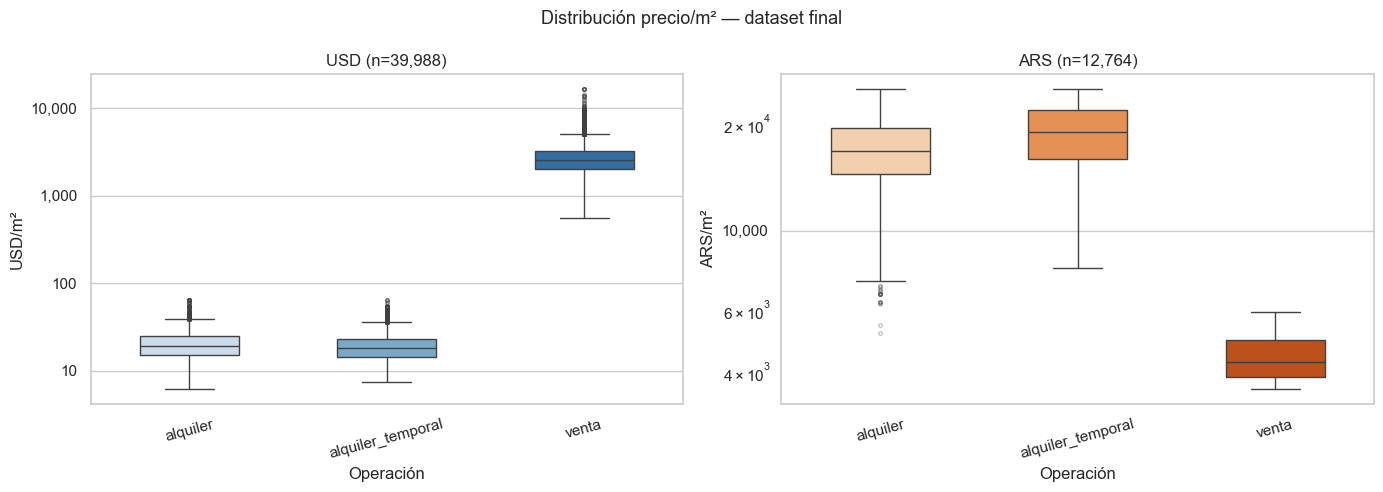

In [63]:
print("=" * 55)
print(f"DATASET FINAL: {len(df_final):,} registros")
print("=" * 55)

# Sanidad: no deben quedar NaN ni infinitos en variables clave
vars_clave = ['precio', 'm2_total', 'precio_por_m2',
              'log_precio', 'log_m2', 'log_precio_m2']
nans = df_final[vars_clave].isna().sum()
infs = (df_final[vars_clave] == np.inf).sum()
assert nans.sum() == 0, f"Hay NaN:\n{nans[nans > 0]}"
assert infs.sum() == 0, f"Hay infinitos:\n{infs[infs > 0]}"
print("OK — sin NaN ni infinitos en variables clave")

# Distribución por segmento
print("\nDistribución por segmento:")
resumen = (
    df_final
    .groupby(['operacion', 'moneda', 'segmento_zona_modelo'])['precio_por_m2']
    .agg(
        n       = 'count',
        p5      = lambda x: x.quantile(0.05),
        mediana = 'median',
        p95     = lambda x: x.quantile(0.95)
    )
    .round(0)
)
print(resumen)

# Gráfico con escala logarítmica en el eje Y para legibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución precio/m² — dataset final', fontsize=13)

for ax, (moneda, palette) in zip(axes, [('usd', 'Blues'), ('ars', 'Oranges')]):
    datos = df_final[df_final['moneda'] == moneda]
    sns.boxplot(
        x='operacion', y='precio_por_m2',
        data=datos, ax=ax,
        palette=palette, width=0.5,
        flierprops=dict(marker='.', markersize=5, alpha=0.3)
    )
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_title(f'{moneda.upper()} (n={len(datos):,})')
    ax.set_xlabel('Operación')
    ax.set_ylabel(f'{moneda.upper()}/m²')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Algo que llama la atención es el valor bajo de los departamentos en venta en ARS. Esto es debido a la poca cantidad de registros de los mismos (40) y a el tipo de departamento que está en oferta en pesos. Estos departamentos suelen ser inmuebles deteriorados que se encuentran en remate.

# 9. EDA - Análisis Univariado

Estadísticos de resumen robustos para las variables numéricas clave.

In [64]:
from scipy.stats import skew, kurtosis

variables_num = ['precio_final', 'm2_total', 'ambientes', 'dormitorios', 'baños', 'antiguedad_años']
variables_presentes = [v for v in variables_num if v in df_final.columns]

resumen = []
for var in variables_presentes:
    serie = df_final[var].dropna()
    resumen.append({
        'variable': var,
        'n': len(serie),
        'media': serie.mean(),
        'mediana': serie.median(),
        'desvio': serie.std(),
        'asimetria': skew(serie),
        'curtosis': kurtosis(serie),
        'p5': serie.quantile(0.05),
        'p25': serie.quantile(0.25),
        'p75': serie.quantile(0.75),
        'p95': serie.quantile(0.95),
    })

pd.DataFrame(resumen).set_index('variable').round(2)

,n,media,mediana,desvio,asimetria,curtosis,p5,p25,p75,p95
variable,,,,,,,,,,
m2_total,52752,70,52,57,7,233,28,38,79,175
ambientes,52752,2,2,1,2,14,1,1,3,4
dormitorios,52752,2,1,1,2,13,1,1,2,3
baños,52752,1,1,1,3,12,1,1,1,3
antiguedad_años,52752,28,25,54,32,"1,159",0,10,40,60


El inmueble mediano tiene aproximadamente 52 m², 2 ambientes, 1 dormitorio, 1 baño y 25 años de antigüedad. La media de superficie total es mayor, cercana a 70 m², lo que sugiere la presencia de propiedades grandes que empujan el promedio hacia arriba.

In [65]:
# Prevalencia de atributos en el dataset
bool_features = ['cochera', 'aire_acond', 'luminoso', 'balcon_aterrazado',
                  'losa_central', 'seguridad', 'apto_credito']
bool_en_df = [c for c in bool_features if c in df_final.columns]

prevalencia = pd.DataFrame({
    'con_atributo': df_final[bool_en_df].sum(),
    'porcentaje (%)': (df_final[bool_en_df].mean() * 100).round(1)
}).sort_values('porcentaje (%)', ascending=False)
print("Prevalencia de atributos en el dataset:")
print(prevalencia)

Prevalencia de atributos en el dataset:
                   con_atributo  porcentaje (%)
luminoso                  31669              60
aire_acond                16347              31
cochera                   15297              29
seguridad                 11440              22
losa_central               5237              10
balcon_aterrazado          4884               9
apto_credito               3842               7


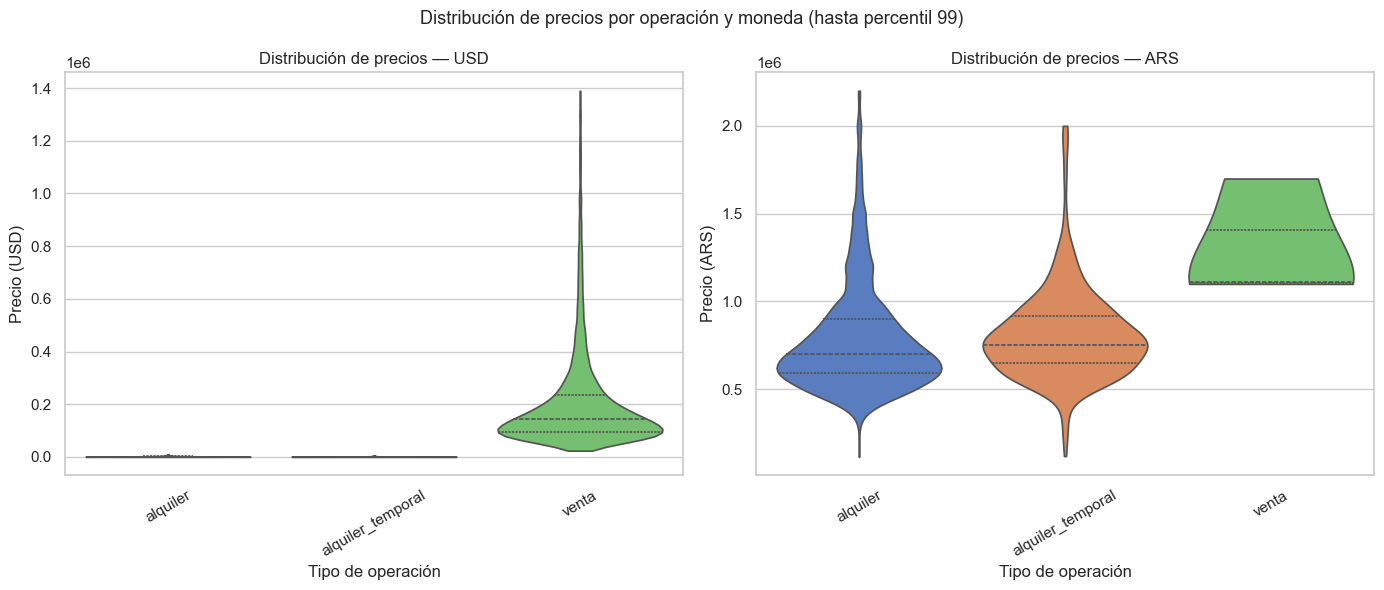

In [66]:
# Violin plot de precio_final por operación (separado por moneda)
# Usamos percentil 99 para limitar el eje y y que los outliers no distorsionen la visibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, moneda in zip(axes, ['usd', 'ars']):
    subset = df_final[
        df_final['moneda'] == moneda
    ][['operacion', 'precio']].dropna()
    
    # Limite por percentil 99 para cada segmento
    p99 = subset['precio'].quantile(0.99)
    subset = subset[subset['precio'] <= p99]
    
    sns.violinplot(data=subset, x='operacion', y='precio', ax=ax,
                   palette='muted', inner='quartile', cut=0)
    ax.set_title(f'Distribución de precios — {moneda.upper()}', fontsize=12)
    ax.set_xlabel('Tipo de operación')
    ax.set_ylabel(f'Precio ({moneda.upper()})')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Distribución de precios por operación y moneda (hasta percentil 99)', fontsize=13)
plt.tight_layout()
plt.show()

# 10. EDA - Análisis Bivariado y Multivariado

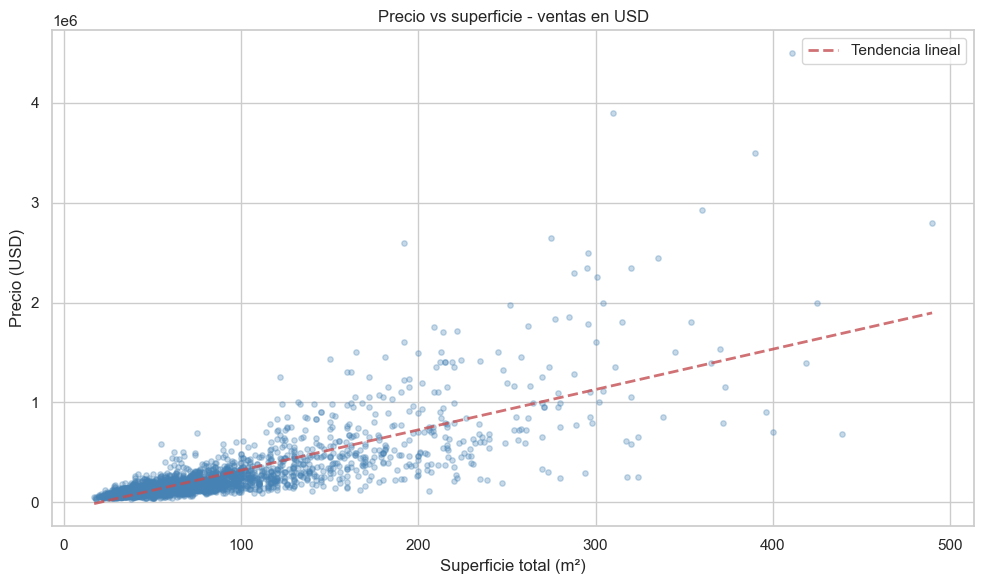

In [67]:
# Scatter de precio_final vs m2_total para ventas en USD
# Usamos una muestra aleatoria para evitar sobrecarga visual
subset_scatter = df_final[
    (df_final['moneda'] == 'usd') & 
    (df_final['operacion'] == 'venta') &
    df_final['precio'].notna() &
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 5) &
    (df_final['m2_total'] < 500)  # filtramos propiedades con m2 absurdo
].sample(min(3000, len(df_final)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    subset_scatter['m2_total'], 
    subset_scatter['precio'],
    alpha=0.3, s=15, color='steelblue'
)

# Línea de tendencia (regresión simple para orientación visual)
z = np.polyfit(subset_scatter['m2_total'].dropna(), 
               subset_scatter['precio'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(subset_scatter['m2_total'].min(), subset_scatter['m2_total'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, label='Tendencia lineal')

ax.set_xlabel('Superficie total (m²)')
ax.set_ylabel('Precio (USD)')
ax.set_title('Precio vs superficie - ventas en USD')
ax.legend()
plt.tight_layout()
plt.show()

Se puede sospechar una relación lineal entre el precio y la superficie total del inmueble, más que nada en superficies menores a los 100 metros cuadrados. Tiene sentido que, cuanto mayor la superficie total, más de lujo es la propiedad y por ende más difícil es relacionarla linealmente con el precio.

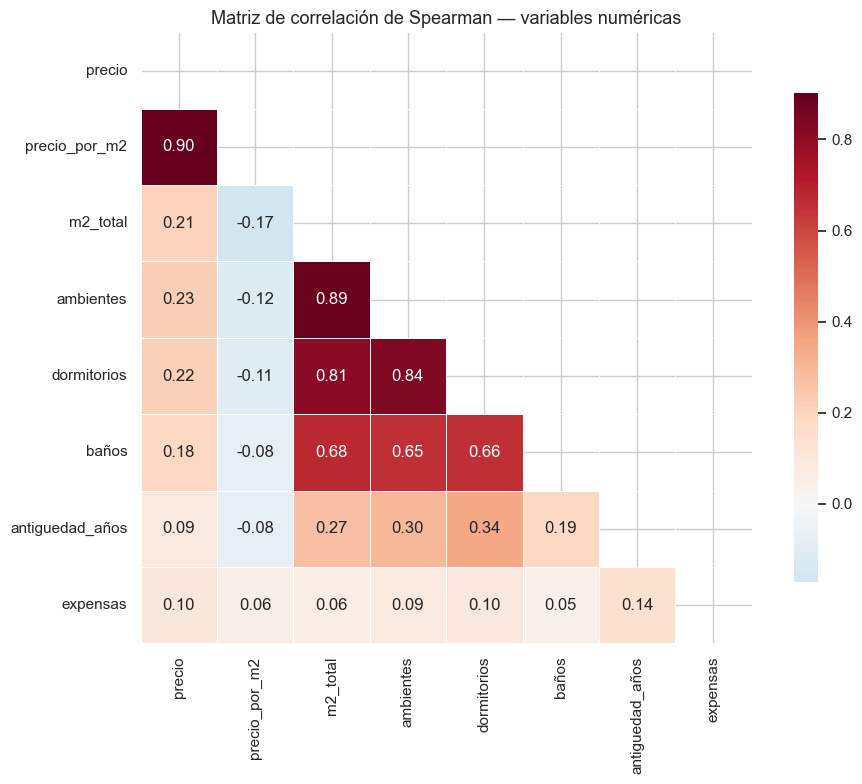

In [68]:
# Heatmap de correlación entre variables numéricas clave
# Usamos Spearman por la no-normalidad de las distribuciones de precio
vars_correlacion = [v for v in ['precio', 'precio_por_m2', 'm2_total', 
                                 'ambientes', 'dormitorios', 'baños', 
                                 'antiguedad_años', 'expensas'] 
                    if v in df_final.columns]

corr_matrix = df_final[vars_correlacion].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación de Spearman — variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

Las variables 'ambientes' y 'm2_total' tienen una correlación muy alta, al igual que 'ambientes' y 'dormitorios'. Esto tiene sentido ya que, cuantos más ambientes mayor es la propiedad y cuantos más dormitorios, más ambientes tiene. 

# 11. Analisis geografico:

In [69]:
import requests
import geopandas as gpd

# Descargamos el GeoJSON oficial de barrios de la Ciudad de Buenos Aires desde datos abiertos
url_geojson = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson"
geojson_barrios = requests.get(url_geojson).json()

nombres_geojson = {f["properties"]["nombre"] for f in geojson_barrios["features"]}

df_filtrado = df_final[df_final["barrio_oficial"].isin(nombres_geojson)]
conteo = df_filtrado.groupby("barrio_oficial").size().reset_index(name="cantidad")

nombres_df = set(conteo["barrio_oficial"])
print("Barrios sin coincidencia en el GeoJSON:", nombres_df - nombres_geojson)


Barrios sin coincidencia en el GeoJSON: set()


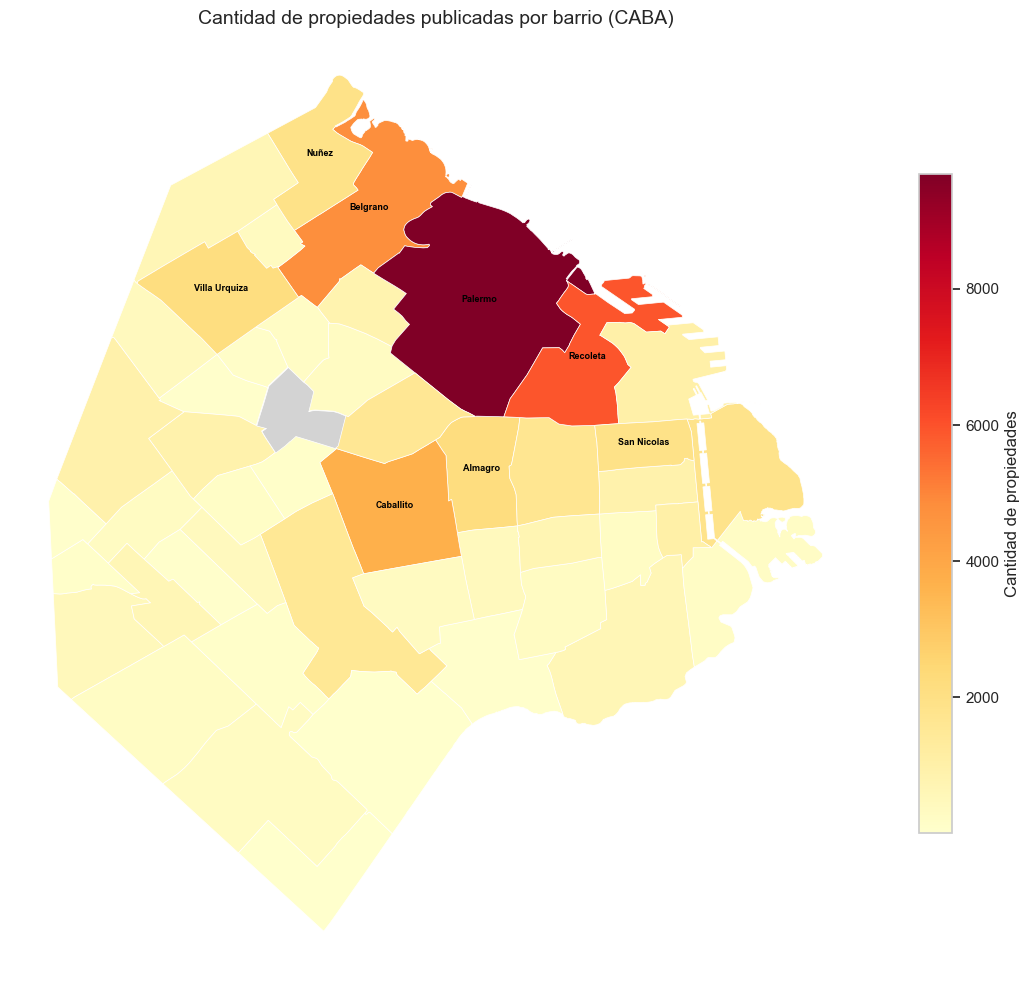

In [70]:
# Construimos el GeoDataFrame de barrios y lo mergeamos con el conteo de propiedades
gdf = gpd.GeoDataFrame.from_features(geojson_barrios["features"])
gdf = gdf.rename(columns={"nombre": "barrio_oficial"})
gdf = gdf.set_crs("EPSG:4326")

gdf_conteo = gdf.merge(conteo, on="barrio_oficial", how="left")

# --- Mapa: cantidad de propiedades por barrio ---
fig, ax = plt.subplots(figsize=(12, 10))

gdf_conteo.plot(
    column="cantidad",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Cantidad de propiedades", "shrink": 0.7},
    missing_kwds={"color": "lightgray", "label": "Sin datos"},
    ax=ax,
)

# Anotamos los top-8 barrios por cantidad
top_barrios = gdf_conteo.nlargest(8, "cantidad")
for _, row in top_barrios.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["barrio_oficial"],
        xy=(centroide.x, centroide.y),
        ha="center",
        fontsize=6.5,
        color="black",
        fontweight="bold",
    )

ax.set_title("Cantidad de propiedades publicadas por barrio (CABA)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


Como se puede ver en el mapa, los barrios de Palermo, Belgrano, Recoleta y Caballito son los más representados en las bases de datos.

A continuación se presentan mapas del precio mediano por barrio, separados por tipo de operación y moneda. Usamos la columna `precio` (ya limpia de texto) del DataFrame principal. Para venta e inmuebles con precio disponible se calcula también el precio mediano por m².

In [71]:
def graficar_mapa_precio(gdf_base, df_source, filtro_operacion, filtro_moneda,
                          columna_precio, titulo, etiqueta_leyenda,
                          cmap="Blues", top_n=8, fmt_precio="{:,.0f}"):
    """
    Genera un mapa coroplético de precio mediano por barrio usando geopandas + matplotlib.

    Parámetros
    ----------
    gdf_base           : GeoDataFrame con la geometría de los barrios (columna 'barrio_oficial')
    df_source          : DataFrame con columnas barrio_oficial, operacion, moneda y columna_precio
    filtro_operacion   : str, valor de la columna 'operacion' a filtrar
    filtro_moneda      : str, valor de la columna 'moneda' a filtrar
    columna_precio     : str, columna numérica a agregar con la mediana
    titulo             : str, título del mapa
    etiqueta_leyenda   : str, etiqueta de la barra de colores
    cmap               : str, colormap de matplotlib
    top_n              : int, cantidad de barrios a anotar
    fmt_precio         : str, formato para el texto de anotación
    """
    # Filtrado y cálculo de mediana por barrio
    mask = (
        (df_source["operacion"] == filtro_operacion)
        & (df_source["moneda"] == filtro_moneda)
        & df_source[columna_precio].notna()
        & (df_source[columna_precio] > 0)
        & df_source["barrio_oficial"].notna()
    )
    estadisticas = (
        df_source[mask]
        .groupby("barrio_oficial")[columna_precio]
        .median()
        .reset_index()
        .rename(columns={columna_precio: "precio_mediano"})
    )

    gdf_merge = gdf_base.merge(estadisticas, on="barrio_oficial", how="left")

    fig, ax = plt.subplots(figsize=(12, 10))

    gdf_merge.plot(
        column="precio_mediano",
        cmap=cmap,
        linewidth=0.5,
        edgecolor="white",
        legend=True,
        legend_kwds={"label": etiqueta_leyenda, "shrink": 0.7},
        missing_kwds={"color": "lightgray", "label": "Sin datos"},
        ax=ax,
    )

    # Anotamos los top-N barrios con mayor precio mediano
    top = gdf_merge.dropna(subset=["precio_mediano"]).nlargest(top_n, "precio_mediano")
    for _, row in top.iterrows():
        centroide = row.geometry.centroid
        ax.annotate(
            row["barrio_oficial"],
            xy=(centroide.x, centroide.y),
            ha="center",
            fontsize=6,
            color="black",
            fontweight="bold",
        )

    ax.set_title(titulo, fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


In [72]:
# df_geo: registros con barrio_oficial válido para análisis geoespacial
# Nota: m2_total y precio_por_m2 solo estarán disponibles si la sección de
# parseo de detalles/descripción ya fue ejecutada previamente.
df_geo = df_filtrado.copy()

if "m2_total" in df.columns:
    df_geo["m2_total"] = df.loc[df_geo.index, "m2_total"]
    mask_m2 = df_geo["m2_total"].notna() & (df_geo["m2_total"] > 5) & df_geo["precio"].notna() & (df_geo["precio"] > 0)
    df_geo.loc[mask_m2, "precio_por_m2"] = df_geo.loc[mask_m2, "precio"] / df_geo.loc[mask_m2, "m2_total"]
    print(f"Registros con precio_por_m2 calculado: {mask_m2.sum():,}")
else:
    print("m2_total aún no disponible (ejecutar sección de parseo de detalles primero).")

print(f"Registros en df_geo: {len(df_geo):,}")
print(df_geo[["operacion", "moneda"]].value_counts())


m2_total aún no disponible (ejecutar sección de parseo de detalles primero).
Registros en df_geo: 52,533
operacion          moneda
venta              usd       28513
alquiler           ars       12243
                   usd        6153
alquiler_temporal  usd        5185
                   ars         435
venta              ars           4
Name: count, dtype: int64


### Precio mediano de venta (USD) por barrio

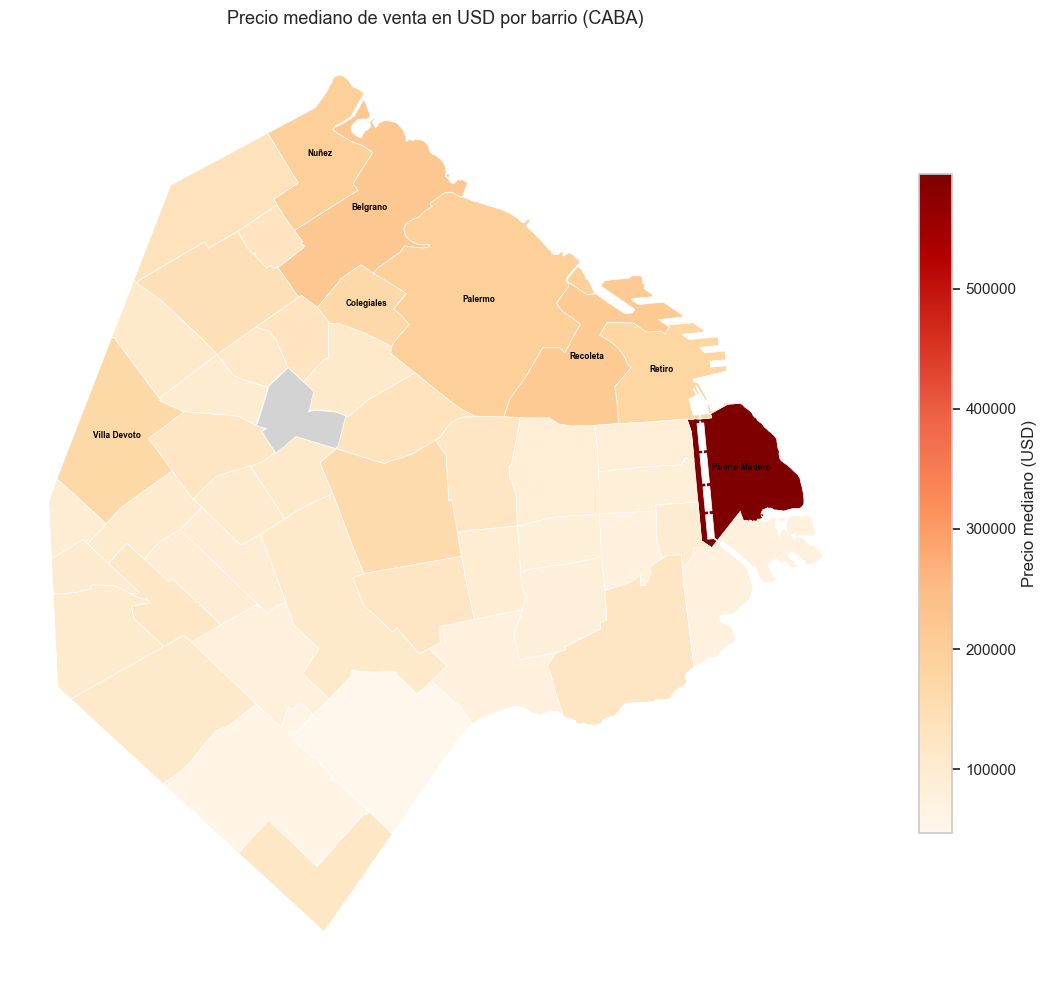

In [73]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="venta",
    filtro_moneda="usd",
    columna_precio="precio",
    titulo="Precio mediano de venta en USD por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (USD)",
    cmap="OrRd",
    top_n=8,
)


### Precio mediano de alquiler (ARS) por barrio

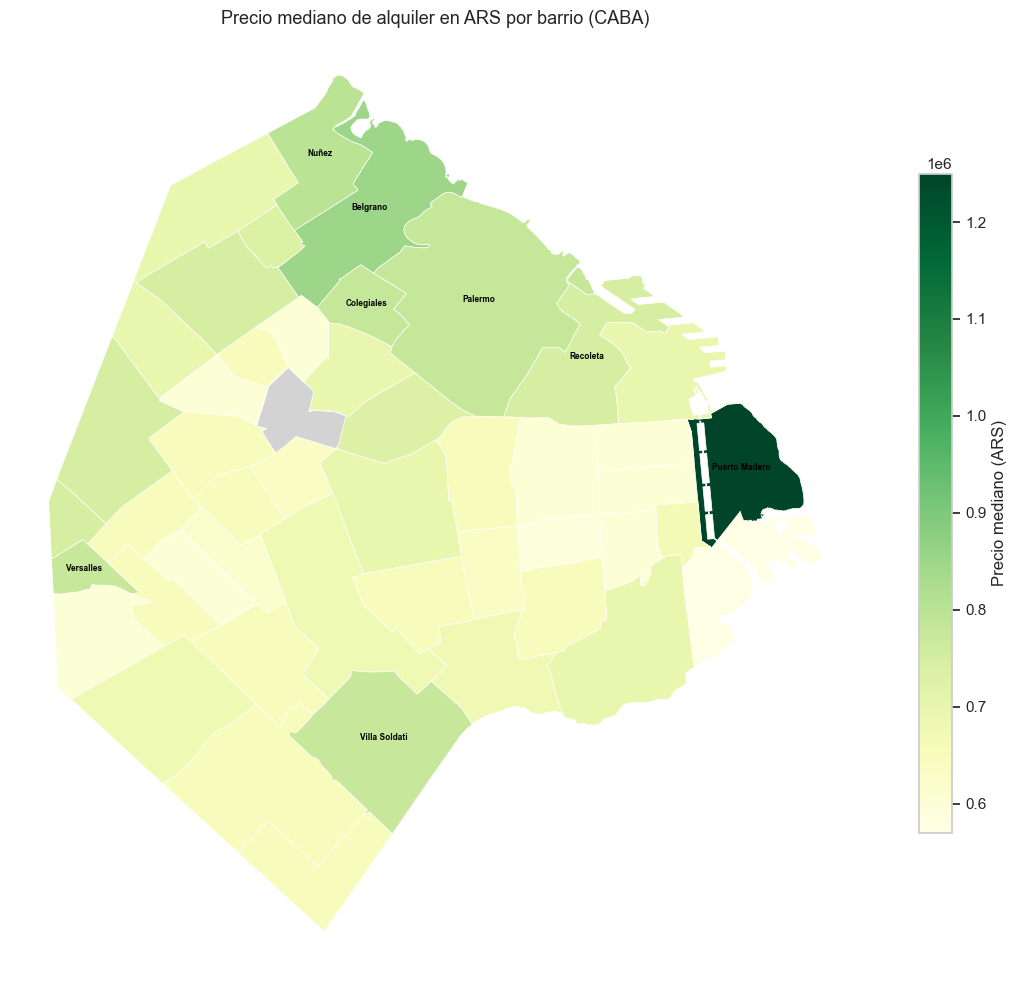

In [74]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="alquiler",
    filtro_moneda="ars",
    columna_precio="precio",
    titulo="Precio mediano de alquiler en ARS por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (ARS)",
    cmap="YlGn",
    top_n=8,
)


### Precio mediano por m² en venta (USD) por barrio

Este mapa muestra el precio mediano por metro cuadrado para propiedades en venta con precio en dólares. La columna `m2_total` proviene del parseo de la columna `detalles` (superficie total o cubierta). Solo se incluyen propiedades con `m2_total > 5 m²`.

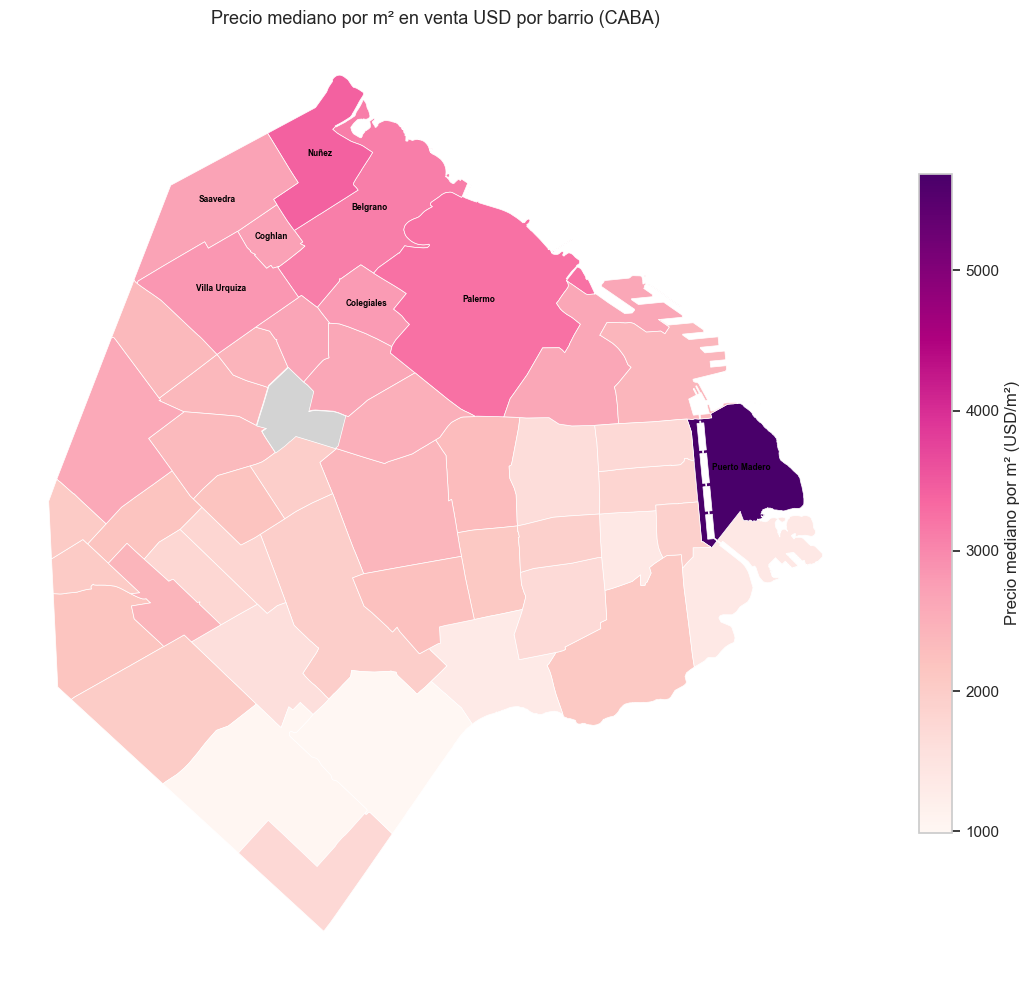

In [75]:
if "precio_por_m2" in df_geo.columns:
    graficar_mapa_precio(
        gdf_base=gdf,
        df_source=df_geo,
        filtro_operacion="venta",
        filtro_moneda="usd",
        columna_precio="precio_por_m2",
        titulo="Precio mediano por m² en venta USD por barrio (CABA)",
        etiqueta_leyenda="Precio mediano por m² (USD/m²)",
        cmap="RdPu",
        top_n=8,
    )
else:
    print("No se pudo generar el mapa: la columna 'precio_por_m2' no está disponible.")
    print("Asegurate de ejecutar la celda de parseo de 'detalles' antes de esta.")


A través de todos los mercados, barrios como Puerto Madero, Palermo, Recoleta y Belgrano mantienen los precios más altos. 

In [76]:
tabla_barrio_operacion = (
    df.groupby(["barrio_oficial", "operacion"])
      .size()
      .unstack(fill_value=0)
)

tabla_barrio_operacion["Total_barrio"] = tabla_barrio_operacion.sum(axis=1)
tabla_barrio_operacion.loc["Total_operacion"] = tabla_barrio_operacion.sum(axis=0)

tabla_barrio_operacion

operacion,alquiler,alquiler_temporal,venta,Total_barrio
barrio_oficial,,,,
Agronomia,30,1,92,123
Almagro,805,412,1446,2663
Balvanera,621,195,1156,1972
Barracas,220,15,488,723
Belgrano,1812,604,3322,5738
Boedo,175,15,352,542
Caballito,1500,239,2567,4306
Chacarita,122,41,203,366
Coghlan,96,26,311,433


La cantidad mínima de propiedades de los barrios se encuentra en Villa Riachuelo, con 5 propiedades. Asimismo, la operación con la menor cantidad de propiedades disponibles es 'alquiler_temporal'. Por ende, esperamos que las conclusiones más robustas del análisis sean sobre los barrios con mayor cantidad de propiedades (como los mencionados previamente), pero esperamos obtener conclusiones fuertes sobre los tres tipos de operaciones ya que 'alquiler_temporal' siendo la columna con la menor cantidad de filas presenta más de 8000 de las mismas.

# 12. Inferencia Estadística - Validación de Hipótesis

Transitamos de la exploración visual a la confirmación formal. Para cada hipótesis documentamos:
- **H₀** (hipótesis nula)
- **Estadístico y p-valor**
- **Decisión** (rechazar o no rechazar H₀ con α = 0.05)

In [77]:
from scipy.stats import chi2_contingency, f_oneway, spearmanr

# --- TEST 1: Chi-cuadrado ---
# H₀: el tipo de operación y tener cochera son variables independientes
# H₁: existe asociación entre el tipo de operación y la presencia de cochera

tabla_contingencia = pd.crosstab(df_final['operacion'], df_final['cochera'])
chi2, p_chi2, dof, expected = chi2_contingency(tabla_contingencia)

print("=== TEST 1: Chi-cuadrado — operación vs cochera ===")
print(f"\nTabla de contingencia:")
print(tabla_contingencia)
print(f"\nEstadístico χ² = {chi2:.2f}")
print(f"Grados de libertad = {dof}")
print(f"p-valor = {p_chi2:.4e}")
print(f"\n→ {'Rechazamos H₀' if p_chi2 < 0.05 else 'No rechazamos H₀'} (α = 0.05)")
if p_chi2 < 0.05:
    print("  Conclusión: existe asociación estadísticamente significativa entre el")
    print("  tipo de operación y la presencia de cochera.")

=== TEST 1: Chi-cuadrado — operación vs cochera ===

Tabla de contingencia:
cochera                0      1
operacion                      
alquiler           14221   4260
alquiler_temporal   4846    775
venta              18388  10262

Estadístico χ² = 1596.43
Grados de libertad = 2
p-valor = 0.0000e+00

→ Rechazamos H₀ (α = 0.05)
  Conclusión: existe asociación estadísticamente significativa entre el
  tipo de operación y la presencia de cochera.


In [78]:
# --- TEST 2: ANOVA de un factor + Kruskal-Wallis (validación no paramétrica) ---
# H₀: el precio_por_m2 promedio es igual en los top-5 barrios (ventas USD)
# H₁: al menos un barrio tiene media diferente
#
# ANOVA asume normalidad intra-grupos; Jarque-Bera la rechazó para los precios.
# Sin embargo, con muestras grandes el Teorema Central del Límite hace que el
# estadístico F sea robusto a la no-normalidad. Se complementa con Kruskal-Wallis,
# el equivalente no paramétrico de ANOVA (no asume distribución), como validación.
from scipy.stats import kruskal

top5_barrios = (
    df_final[
        (df_final['operacion'] == 'venta') &
        (df_final['moneda'] == 'usd') &
        df_final['precio_por_m2'].notna()
    ]
    .groupby('barrio_oficial')['precio_por_m2']
    .count()
    .nlargest(5)
    .index.tolist()
)

grupos = [
    df_final[
        (df_final['barrio_oficial'] == b) &
        (df_final['operacion'] == 'venta') &
        (df_final['moneda'] == 'usd')
    ]['precio_por_m2'].dropna().values
    for b in top5_barrios
]

f_stat, p_anova = f_oneway(*grupos)
kw_stat, p_kruskal = kruskal(*grupos)

print('=== TEST 2: ANOVA + Kruskal-Wallis — precio/m² entre top-5 barrios (venta USD) ===')
print(f'\nBarrios analizados: {top5_barrios}')
for barrio, grupo in zip(top5_barrios, grupos):
    print(f'  {barrio:25s}: n={len(grupo):,}, mediana={np.median(grupo):,.0f} USD/m²')

print(f'\n--- ANOVA (paramétrico, asume normalidad intra-grupos) ---')
print(f'Estadístico F = {f_stat:.2f}')
print(f'p-valor       = {p_anova:.4e}')
print(f"→ {'Rechazamos H₀' if p_anova < 0.05 else 'No rechazamos H₀'} (α = 0.05)")

print(f'\n--- Kruskal-Wallis (no paramétrico, no asume normalidad) ---')
print(f'Estadístico H = {kw_stat:.2f}')
print(f'p-valor       = {p_kruskal:.4e}')
print(f"→ {'Rechazamos H₀' if p_kruskal < 0.05 else 'No rechazamos H₀'} (α = 0.05)")

if p_anova < 0.05 and p_kruskal < 0.05:
    print('\nAmbos tests coinciden: el precio por m² difiere significativamente entre barrios.')
    print('La ubicación geográfica es un factor con impacto estadístico robusto en el precio.')
elif p_anova < 0.05 and p_kruskal >= 0.05:
    print('\nDiscrepancia: ANOVA rechaza H₀ pero Kruskal-Wallis no.')
    print('El resultado del ANOVA puede estar influenciado por la no-normalidad.')
else:
    print('\nAmbos tests no rechazan H₀: no hay diferencia significativa entre barrios.')


=== TEST 2: ANOVA + Kruskal-Wallis — precio/m² entre top-5 barrios (venta USD) ===

Barrios analizados: ['Palermo', 'Belgrano', 'Recoleta', 'Caballito', 'Villa Urquiza']
  Palermo                  : n=4,269, mediana=3,241 USD/m²
  Belgrano                 : n=2,811, mediana=3,113 USD/m²
  Recoleta                 : n=2,719, mediana=2,635 USD/m²
  Caballito                : n=2,222, mediana=2,388 USD/m²
  Villa Urquiza            : n=1,289, mediana=2,838 USD/m²

--- ANOVA (paramétrico, asume normalidad intra-grupos) ---
Estadístico F = 427.07
p-valor       = 0.0000e+00
→ Rechazamos H₀ (α = 0.05)

--- Kruskal-Wallis (no paramétrico, no asume normalidad) ---
Estadístico H = 1684.53
p-valor       = 0.0000e+00
→ Rechazamos H₀ (α = 0.05)

Ambos tests coinciden: el precio por m² difiere significativamente entre barrios.
La ubicación geográfica es un factor con impacto estadístico robusto en el precio.


In [79]:
# --- TEST 2b: T de Welch — media de log(precio) entre monedas dentro de cada operación ---
# H₀: la media de log(1 + precio) es igual para propiedades en USD y en ARS
#     dentro de cada tipo de operación (alquiler, alquiler_temporal, venta)
# H₁: las medias son distintas
#
# Se usa la variante de Welch (equal_var=False) que no asume varianzas iguales
# entre grupos, lo cual es apropiado dado que los precios en USD y ARS presentan
# dispersiones muy distintas incluso en escala logarítmica.
#
# La transformación log(1+precio) hace la comparación de magnitudes relativa:
# se contrasta si las propiedades en USD están en un nivel de precio
# estadísticamente distinto al de las propiedades en ARS, operación por operación.
from scipy.stats import ttest_ind

print('=== TEST 2b: T de Welch — log(precio) por moneda dentro de cada operación ===')
print('H₀: media de log(1+precio) igual entre USD y ARS  |  H₁: distintas  |  α = 0.05')
print()
header = f"{'Operación':20s}  {'n_USD':>7s}  {'n_ARS':>7s}  "\
         f"{'media_USD':>10s}  {'media_ARS':>10s}  {'t':>8s}  {'p-valor':>12s}  Decisión"
print(header)
print('-' * len(header))

for op in ['alquiler', 'alquiler_temporal', 'venta']:
    usd_vals = df_final[
        (df_final['operacion'] == op) & (df_final['moneda'] == 'usd')
    ]['precio'].dropna()
    ars_vals = df_final[
        (df_final['operacion'] == op) & (df_final['moneda'] == 'ars')
    ]['precio'].dropna()

    if len(usd_vals) < 2 or len(ars_vals) < 2:
        print(f'{op:20s}  datos insuficientes')
        continue

    log_usd = np.log1p(usd_vals.values)
    log_ars = np.log1p(ars_vals.values)

    t_stat, p_val = ttest_ind(log_usd, log_ars, equal_var=False)
    decision = 'Rechazar H₀' if p_val < 0.05 else 'No rechazar H₀'
    print(
        f"{op:20s}  {len(usd_vals):>7,}  {len(ars_vals):>7,}  "
        f"{log_usd.mean():>10.3f}  {log_ars.mean():>10.3f}  "
        f"{t_stat:>8.2f}  {p_val:>12.4e}  {decision}"
    )

print()
print('Nota: media_USD y media_ARS son medias de log(1+precio), no precios absolutos.')
print('Una diferencia positiva (USD > ARS en log-escala) implica que los USD tienen')
print('mayor precio relativo, consistente con operar en distintas monedas y mercados.')


=== TEST 2b: T de Welch — log(precio) por moneda dentro de cada operación ===
H₀: media de log(1+precio) igual entre USD y ARS  |  H₁: distintas  |  α = 0.05

Operación               n_USD    n_ARS   media_USD   media_ARS         t       p-valor  Decisión
------------------------------------------------------------------------------------------------
alquiler                6,157   12,324       7.199      13.525   -687.70    0.0000e+00  Rechazar H₀
alquiler_temporal       5,185      436       6.826      13.560   -412.04    0.0000e+00  Rechazar H₀
venta                  28,646        4      12.009      14.619     -4.58    1.9480e-02  Rechazar H₀

Nota: media_USD y media_ARS son medias de log(1+precio), no precios absolutos.
Una diferencia positiva (USD > ARS en log-escala) implica que los USD tienen
mayor precio relativo, consistente con operar en distintas monedas y mercados.


In [80]:
# --- TEST 3: Correlación de Spearman y Pearson ---
# Spearman (ρ): correlación de rango, robusta a no-normalidad y outliers.
#   Es el método principal dado que Jarque-Bera rechazó normalidad.
# Pearson (r): correlación lineal. Se incluye como referencia para evaluar
#   si las relaciones monótonas detectadas por Spearman también son lineales.
#
# H₀ (en ambos tests): no existe correlación (ρ = 0 / r = 0)
from scipy.stats import pearsonr

variables_test = ['ambientes', 'dormitorios', 'baños', 'antiguedad_años']

print('=== TEST 3: Correlación de Spearman y Pearson — precio/m² vs atributos ===')
print('H₀: no existe correlación (ρ = 0 / r = 0)  |  α = 0.05')
print()
header = (f"{'Variable':20s}  {'ρ Spearman':>12s}  {'p Spearman':>12s}  "
          f"{'r Pearson':>12s}  {'p Pearson':>12s}  Decisión (Spearman)")
print(header)
print('-' * len(header))

for var in variables_test:
    if var not in df_final.columns:
        continue
    mask_valid = df_final['precio_por_m2'].notna() & df_final[var].notna()
    if mask_valid.sum() < 30:
        continue
    rho, p_spear = spearmanr(
        df_final.loc[mask_valid, 'precio_por_m2'],
        df_final.loc[mask_valid, var]
    )
    r, p_pear = pearsonr(
        df_final.loc[mask_valid, 'precio_por_m2'],
        df_final.loc[mask_valid, var]
    )
    decision = 'Rechazar H₀' if p_spear < 0.05 else 'No rechazar H₀'
    print(
        f"{var:20s}  {rho:>12.4f}  {p_spear:>12.4e}  "
        f"{r:>12.4f}  {p_pear:>12.4e}  {decision}"
    )

print()
print('Nota: Spearman y Pearson similares → la relación es aproximadamente lineal.')
print('Spearman >> Pearson → relación monótona pero no lineal (probable en precios).')


=== TEST 3: Correlación de Spearman y Pearson — precio/m² vs atributos ===
H₀: no existe correlación (ρ = 0 / r = 0)  |  α = 0.05

Variable                ρ Spearman    p Spearman     r Pearson     p Pearson  Decisión (Spearman)
-------------------------------------------------------------------------------------------------
ambientes                  -0.1226   1.0637e-175       -0.1882    0.0000e+00  Rechazar H₀
dormitorios                -0.1090   5.2443e-139       -0.1798    0.0000e+00  Rechazar H₀
baños                      -0.0760    1.7410e-68       -0.1512   2.6894e-267  Rechazar H₀
antiguedad_años            -0.0816    1.0621e-78       -0.0235    7.0606e-08  Rechazar H₀

Nota: Spearman y Pearson similares → la relación es aproximadamente lineal.
Spearman >> Pearson → relación monótona pero no lineal (probable en precios).


# 13. Selección de variables 

En primer lugar, eliminamos variables que visiblemente no son útiles para realizar el análisis futuro.

In [81]:
df_final.columns

Index(['fecha_scraping', 'posting_id', 'sitio', 'operacion', 'precio', 'calle',
       'altura', 'barrio', 'detalles', 'descripción', 'link', 'amenities',
       'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
       'luminoso', 'balcon_aterrazado', 'barrio_norm', 'barrio_oficial',
       'moneda', 'accesible_movilidad_reducida', 'acepta_caucion',
       'acepta_finaer', 'agua_caliente_central', 'ambientes',
       'antiguedad_años', 'apto_profesional', 'ascensor', 'balcon', 'baulera',
       'baños', 'dependencia_servicio', 'dormitorios', 'gimnasio', 'lavadero',
       'm2_total', 'ofrece_financiacion', 'parrilla', 'permite_mascotas',
       'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'vista_rio',
       'vista_verde', 'expensas', 'sobre_avenida', 'precio_por_m2',
       'precio_por_m2_original', 'segmento_zona', 'segmento_zona_modelo',
       'log_precio', 'log_m2', 'log_precio_m2'],
      dtype='object')

In [82]:
df_final = df_final.drop(columns=[
    'fecha_scraping', 'posting_id', 'sitio', 'detalles', 'descripción', 'link', 'amenities'
])

# Eliminar derivadas del target (evitar data leakage)
df_final = df_final.drop(columns=['precio_por_m2_original', 'log_precio', 'log_m2', 'log_precio_m2'])

# nos quedamos con barrio_oficial es la versión final
df_final = df_final.drop(columns=['barrio', 'barrio_norm'])

print(f"Columnas restantes ({len(df_final.columns)}):")
print(df_final.columns.tolist())

Columnas restantes (44):
['operacion', 'precio', 'calle', 'altura', 'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda', 'accesible_movilidad_reducida', 'acepta_caucion', 'acepta_finaer', 'agua_caliente_central', 'ambientes', 'antiguedad_años', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños', 'dependencia_servicio', 'dormitorios', 'gimnasio', 'lavadero', 'm2_total', 'ofrece_financiacion', 'parrilla', 'permite_mascotas', 'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'vista_rio', 'vista_verde', 'expensas', 'sobre_avenida', 'precio_por_m2', 'segmento_zona', 'segmento_zona_modelo']


Analizamos a las variables binarias y eliminamos a aquellas que están presentes <2% y >95%

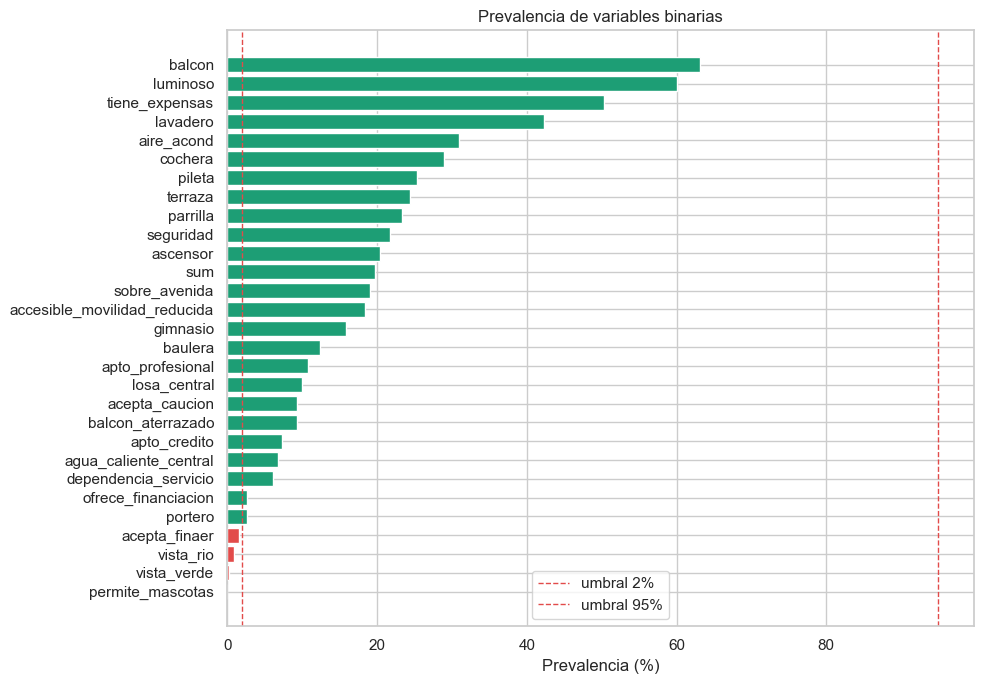


Variables a eliminar por baja variación: ['permite_mascotas', 'vista_verde', 'vista_rio', 'acepta_finaer']


In [83]:
cols_binarias = [
    'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
    'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida',
    'acepta_caucion', 'acepta_finaer', 'agua_caliente_central', 'apto_profesional',
    'ascensor', 'balcon', 'baulera', 'dependencia_servicio', 'gimnasio',
    'lavadero', 'ofrece_financiacion', 'parrilla', 'permite_mascotas',
    'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas',
    'vista_rio', 'vista_verde', 'sobre_avenida'
]
cols_binarias = [c for c in cols_binarias if c in df_final.columns]

prevalencia = df_final[cols_binarias].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#E24B4A' if v < 0.02 or v > 0.95 else '#1D9E75' for v in prevalencia]
ax.barh(prevalencia.index, prevalencia.values * 100, color=colores)
ax.axvline(2,  color='#E24B4A', linestyle='--', linewidth=1, label='umbral 2%')
ax.axvline(95, color='#E24B4A', linestyle='--', linewidth=1, label='umbral 95%')
ax.set_xlabel('Prevalencia (%)')
ax.set_title('Prevalencia de variables binarias')
ax.legend()
plt.tight_layout()
plt.show()

# Variables a eliminar por baja variación
eliminar_prevalencia = prevalencia[(prevalencia < 0.02) | (prevalencia > 0.95)].index.tolist()
print(f"\nVariables a eliminar por baja variación: {eliminar_prevalencia}")
df_final = df_final.drop(columns=eliminar_prevalencia)
cols_binarias = [c for c in cols_binarias if c not in eliminar_prevalencia]

Creamos una variable que cuente la cantidad de amenities finales por propiedad.

In [84]:
df_final['amenities_count'] = df_final[cols_binarias].sum(axis=1)

print("Distribución de amenities_count:")
print(df_final['amenities_count'].describe())

Distribución de amenities_count:
count   52,752
mean         5
std          3
min          0
25%          3
50%          5
75%          7
max         18
Name: amenities_count, dtype: float64


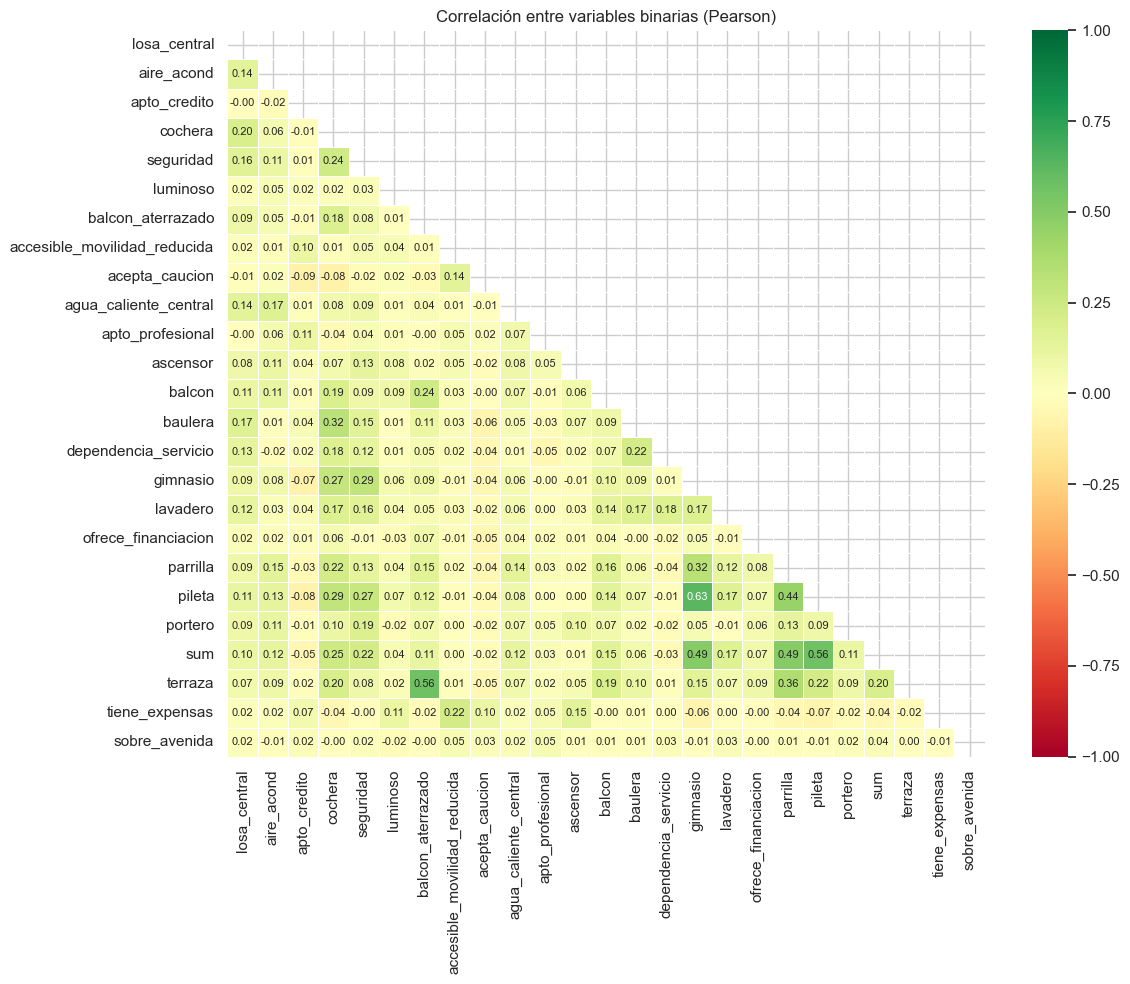


Pares con |r| > 0.85:
Empty DataFrame
Columns: [var_1, var_2, correlacion, correlacion_abs]
Index: []


In [85]:
corr_bin = df_final[cols_binarias].corr(method='pearson')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_bin, dtype=bool))
sns.heatmap(
    corr_bin, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlación entre variables binarias (Pearson)')
plt.tight_layout()
plt.show()

# Tabla de pares con |r| > 0.85
upper = corr_bin.where(np.triu(np.ones(corr_bin.shape), k=1).astype(bool))
pares = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var_1', 'level_1': 'var_2', 0: 'correlacion'})
    .assign(correlacion_abs=lambda x: x['correlacion'].abs())
    .sort_values('correlacion_abs', ascending=False)
)
print("\nPares con |r| > 0.85:")
print(pares[pares['correlacion_abs'] > 0.85].to_string(index=False))

Finalmente, eliminamos la variable 'dormitorios' que tiene una correlación muy alta con 'ambientes' (0.96), como pudimos ver previamente en la matriz de correlación lineal. 

In [86]:
df_final = df_final.drop(columns=['dormitorios'])

# KPIs

Procedemos a definir los KPIs que habíamos planteado en la entrega anterior. Los KPIs son indicadores que dividimos por barrio y decidimos unificar la moneda a dolares para poder armar KPIs que engloben toda la base de datos.

In [88]:
from datetime import date
import requests

def obtener_dolar_oficial():
    hoy = date.today().strftime("%Y-%m-%d")

    try:
        url = f"https://estadisticascambiarias.bcra.gob.ar/estadisticascambiarias/v1.0/Cotizaciones/USD?fecha={hoy}"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['results']['detalle'][0]['tipoCotizacion']
        print(f"✓ [BCRA oficial] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ BCRA oficial falló: {e}")

    try:
        url = "https://apis.datos.gob.ar/series/api/series/?ids=168.1_T_CAMBIOR_D_0_0_26&limit=1&sort=desc"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['data'][0][1]
        print(f"✓ [datos.gob.ar] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ datos.gob.ar falló: {e}")

    try:
        url = "https://dolarapi.com/v1/dolares/oficial"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['venta']
        print(f"✓ [dolarapi.com] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"✗ dolarapi.com falló: {e}")

    print("\n⚠ No se pudo obtener el tipo de cambio de ninguna fuente.")
    print("  Ingresalo manualmente en la siguiente línea:")
    return None

TIPO_DE_CAMBIO_USD = obtener_dolar_oficial()

# 2. Convertimos precio y expensas a USD en una copia del df
df_usd = df_final.copy()
mask_ars = df_usd['moneda'] == 'ars'
df_usd.loc[mask_ars, 'precio']    = df_usd.loc[mask_ars, 'precio']    / TIPO_DE_CAMBIO_USD
df_usd.loc[mask_ars, 'expensas']  = df_usd.loc[mask_ars, 'expensas']  / TIPO_DE_CAMBIO_USD
df_usd['precio_por_m2'] = df_usd['precio'] / df_usd['m2_total']

# 3. DataFrames por operación (ya todo en USD)
ventas      = df_usd[df_usd['operacion'] == 'venta'].copy()
alquileres  = df_usd[df_usd['operacion'] == 'alquiler'].copy()
temporarios = df_usd[df_usd['operacion'] == 'alquiler_temporal'].copy()

# 4. Tabla resumen por barrio: mediana de alquiler y venta (base de KPIs de rentabilidad)
resumen_barrio = pd.DataFrame({
    'alquiler_mediano': alquileres.groupby('barrio_oficial')['precio'].median(),
    'venta_mediana':    ventas.groupby('barrio_oficial')['precio'].median(),
    'expensas_medianas': alquileres.groupby('barrio_oficial')['expensas'].median(),
}).dropna(subset=['alquiler_mediano', 'venta_mediana'])

# 5. Tabla resumen temporario por barrio
segmento_por_barrio = {
    'Palermo': 'premium', 'Recoleta': 'premium',
    'Puerto Madero': 'premium', 'Belgrano': 'premium',
    'Villa Crespo': 'medio', 'Almagro': 'medio',
    'Caballito': 'medio', 'Nuñez': 'medio',
}
ocupacion_por_segmento = {'premium': 0.72, 'medio': 0.62, 'bajo': 0.48}

resumen_temp = pd.DataFrame({
    'tarifa_diaria_mediana': temporarios.groupby('barrio_oficial')['precio'].median(),
    'venta_mediana':         ventas.groupby('barrio_oficial')['precio'].median(),
    'expensas_medianas':     temporarios.groupby('barrio_oficial')['expensas'].median(),
}).dropna(subset=['tarifa_diaria_mediana', 'venta_mediana'])

resumen_temp['segmento'] = resumen_temp.index.map(
    lambda b: segmento_por_barrio.get(b, 'bajo')
)
resumen_temp['ocupacion'] = resumen_temp['segmento'].map(ocupacion_por_segmento)

print(f"Barrios con alquiler + venta:    {len(resumen_barrio)}")
print(f"Barrios con temporario + venta:  {len(resumen_temp)}")


✗ BCRA oficial falló: HTTPSConnectionPool(host='estadisticascambiarias.bcra.gob.ar', port=443): Max retries exceeded with url: /estadisticascambiarias/v1.0/Cotizaciones/USD?fecha=2026-05-11 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000221DE482150>: Failed to resolve 'estadisticascambiarias.bcra.gob.ar' ([Errno 11001] getaddrinfo failed)"))
✓ [datos.gob.ar] Dólar oficial al 2026-05-11: $ 1,415.00 ARS/USD
Barrios con alquiler + venta:    48
Barrios con temporario + venta:  41


Utilizamos la ocupacion por segmento (premium, medio, básico) según AirDna en el caso de alquiler temporario. 

### KPI 1 — Rentabilidad Bruta Largo Plazo


In [89]:
# Fórmula: (Alquiler Mensual × 12) / Precio Venta

kpi1 = resumen_barrio.copy()
kpi1['rentabilidad_bruta_pct'] = (
    (kpi1['alquiler_mediano'] * 12) / kpi1['venta_mediana'] * 100
).round(2)
kpi1 = kpi1.sort_values('rentabilidad_bruta_pct', ascending=False)

print("=== KPI 1: Rentabilidad Bruta Largo Plazo (%) — USD ===")
print(kpi1[['alquiler_mediano', 'venta_mediana', 'rentabilidad_bruta_pct']])


=== KPI 1: Rentabilidad Bruta Largo Plazo (%) — USD ===
                   alquiler_mediano  venta_mediana  rentabilidad_bruta_pct
barrio_oficial                                                            
Villa Soldati                   548         47,000                      14
Villa Lugano                    459         60,000                       9
Nueva Pompeya                   495         75,000                       8
Constitucion                    459         75,000                       7
Parque Avellaneda               459         78,000                       7
Monserrat                       500         87,000                       7
La Boca                         417         73,640                       7
Villa Real                      530         95,000                       7
Parque Patricios                459         83,000                       7
Chacarita                       600        110,000                       7
San Telmo                       530         

### KPI 2 — Recupero de Inversión Largo Plazo


In [90]:
# Fórmula: Precio Venta / (Alquiler Mensual × 12)
# Resultado: años necesarios para recuperar la inversión
# Es el inverso del KPI 1, por lo que reutilizamos el mismo DataFrame.

kpi2 = kpi1.copy()
kpi2['años_recupero'] = (100 / kpi2['rentabilidad_bruta_pct']).round(1)
kpi2 = kpi2.sort_values('años_recupero', ascending=True)

print("=== KPI 2: Recupero de Inversión (años) — USD ===")
print(kpi2[['alquiler_mediano', 'venta_mediana', 'años_recupero']])


=== KPI 2: Recupero de Inversión (años) — USD ===
                   alquiler_mediano  venta_mediana  años_recupero
barrio_oficial                                                   
Villa Soldati                   548         47,000              7
Villa Lugano                    459         60,000             11
Nueva Pompeya                   495         75,000             13
Constitucion                    459         75,000             14
Parque Avellaneda               459         78,000             14
Monserrat                       500         87,000             14
La Boca                         417         73,640             15
Villa Real                      530         95,000             15
Parque Patricios                459         83,000             15
San Telmo                       530         97,500             15
Chacarita                       600        110,000             15
San Nicolas                     480         88,800             15
Versalles                 

### KPI 3 - Precio por metro cuadrado

In [91]:
# Fórmula: Precio / m² (columna precio_por_m2 recalculada en df_usd)

kpi3 = (
    df_usd[df_usd['precio_por_m2'].notna()]
    .groupby(['barrio_oficial', 'operacion'])['precio_por_m2']
    .agg(
        propiedades='count',
        precio_m2_mediano='median',
        precio_m2_promedio='mean'
    )
    .round(0)
    .sort_values(['operacion', 'precio_m2_mediano'], ascending=[True, False])
)

print("=== KPI 3: Precio por m² — USD ===")
print(kpi3)


=== KPI 3: Precio por m² — USD ===
                          propiedades  precio_m2_mediano  precio_m2_promedio
barrio_oficial operacion                                                    
Puerto Madero  alquiler           999                 26                  28
Palermo        alquiler          3506                 16                  18
Nuñez          alquiler           587                 15                  17
Belgrano       alquiler          1522                 14                  16
Chacarita      alquiler            96                 14                  15
...                               ...                ...                 ...
La Boca        venta              153              1,393               1,543
Constitucion   venta              162              1,391               1,450
Nueva Pompeya  venta               41              1,333               1,327
Villa Lugano   venta              199              1,040               1,323
Villa Soldati  venta               18    

### KPI 4 — Rentabilidad Neta Largo Plazo 


In [92]:
# Fórmula: Rentabilidad Bruta - Costo Anual de Expensas (ambos en % del precio de venta)
# Las expensas ya están convertidas a USD en df_usd.

kpi4 = kpi1[['alquiler_mediano', 'venta_mediana', 'rentabilidad_bruta_pct']].copy()
kpi4['expensas_medianas'] = resumen_barrio['expensas_medianas'].fillna(0)

kpi4['costo_expensas_pct'] = (
    (kpi4['expensas_medianas'] * 12) / kpi4['venta_mediana'] * 100
).round(2).fillna(0)

kpi4['rent_neta_pct'] = (kpi4['rentabilidad_bruta_pct'] - kpi4['costo_expensas_pct']).round(2)
kpi4 = kpi4.sort_values('rent_neta_pct', ascending=False)

print("=== KPI 4: Rentabilidad Neta Largo Plazo (%) — USD ===")
print(kpi4[['alquiler_mediano', 'venta_mediana', 'expensas_medianas',
            'rentabilidad_bruta_pct', 'costo_expensas_pct', 'rent_neta_pct']])


=== KPI 4: Rentabilidad Neta Largo Plazo (%) — USD ===
                   alquiler_mediano  venta_mediana  expensas_medianas  \
barrio_oficial                                                          
Villa Soldati                   548         47,000                  0   
Villa Lugano                    459         60,000                  0   
Nueva Pompeya                   495         75,000                  0   
Monserrat                       500         87,000                  0   
Villa Real                      530         95,000                  0   
San Telmo                       530         97,500                  0   
Versalles                       565        107,000                  0   
Parque Avellaneda               459         78,000                 56   
Constitucion                    459         75,000                 75   
Floresta                        459         93,450                  0   
San Nicolas                     480         88,800                 54

Para entender verdaderamente cuál es el barrio con mayor renta neta, hay que considerar que no tenemos valores de expensas de todos los barrios. 

### KPI 5 — Precio/m² relativo por barrio


Realizamos el precio del metro cuadrado relativo solo con las propiedades en dolares, debido a que las propiedades en venta en pesos son muy pocas (40)

In [93]:
# Fórmula: Precio/m² de la propiedad / Mediana Precio/m² de su barrio

df_ventas_m2 = ventas[ventas['precio_por_m2'].notna() & (ventas['precio_por_m2'] > 0)].copy()

mediana_por_barrio = df_ventas_m2.groupby('barrio_oficial')['precio_por_m2'].median()
df_ventas_m2['precio_m2_mediano_barrio'] = df_ventas_m2['barrio_oficial'].map(mediana_por_barrio)
df_ventas_m2['precio_m2_relativo'] = (
    df_ventas_m2['precio_por_m2'] / df_ventas_m2['precio_m2_mediano_barrio']
).round(3)

kpi5_barrios = (
    mediana_por_barrio.rename('precio_m2_mediano').reset_index()
    .merge(
        df_ventas_m2.groupby('barrio_oficial').size().rename('propiedades').reset_index(),
        on='barrio_oficial'
    )
    .sort_values('precio_m2_mediano', ascending=False)
    .set_index('barrio_oficial')
)

oportunidades = df_ventas_m2[
    df_ventas_m2['precio_m2_relativo'] < 1
][['barrio_oficial', 'precio', 'm2_total', 'precio_por_m2', 'precio_m2_mediano_barrio', 'precio_m2_relativo']]\
.sort_values('precio_m2_relativo')

print("=== KPI 5: Mediana Precio/m² por Barrio — Ventas USD ===")
print(kpi5_barrios)
print(f"\n=== Propiedades con precio_m2_relativo < 1 (más baratas que su barrio): {len(oportunidades):,} ===")
print(oportunidades.head(20))


=== KPI 5: Mediana Precio/m² por Barrio — Ventas USD ===
                   precio_m2_mediano  propiedades
barrio_oficial                                   
Puerto Madero                  5,676          579
Nuñez                          3,431         1179
Palermo                        3,241         4269
Belgrano                       3,112         2813
Villa Urquiza                  2,838         1289
Colegiales                     2,805          463
Coghlan                        2,730          279
Saavedra                       2,683          417
Villa Ortuzar                  2,667          147
Recoleta                       2,635         2719
Chacarita                      2,634          175
Villa Devoto                   2,602          592
Villa Crespo                   2,508          937
Parque Chas                    2,432           87
Villa Luro                     2,414          488
Caballito                      2,388         2222
Retiro                         2,388       

### KPI 6 — Rentabilidad Bruta Temporario


In [94]:
# Fórmula: (Tarifa Diaria × 365 × Ocupación) / Precio Venta

kpi6 = resumen_temp.copy()
kpi6['ingreso_anual_estimado'] = (
    kpi6['tarifa_diaria_mediana'] * 365 * kpi6['ocupacion']
).round(2)
kpi6['rent_bruta_temp_pct'] = (
    kpi6['ingreso_anual_estimado'] / kpi6['venta_mediana'] * 100
).round(2)
kpi6 = kpi6.sort_values('rent_bruta_temp_pct', ascending=False)

print("=== KPI 6: Rentabilidad Bruta Temporario — USD ===")
print(kpi6[['segmento', 'ocupacion', 'tarifa_diaria_mediana',
            'ingreso_anual_estimado', 'venta_mediana', 'rent_bruta_temp_pct']])


=== KPI 6: Rentabilidad Bruta Temporario — USD ===
                  segmento  ocupacion  tarifa_diaria_mediana  \
barrio_oficial                                                 
Parque Avellaneda     bajo          0                  1,000   
Nueva Pompeya         bajo          0                    925   
Villa Luro            bajo          0                  1,300   
Constitucion          bajo          0                    633   
La Boca               bajo          0                    600   
Coghlan               bajo          0                    980   
Chacarita             bajo          0                    800   
Monserrat             bajo          0                    625   
Almagro              medio          1                    671   
Villa Crespo         medio          1                    710   
Boedo                 bajo          0                    650   
Palermo            premium          1                    900   
San Nicolas           bajo          0                

### KPI 7 — Índice bruto modalidad óptima

In [95]:
# Fórmula: Rentabilidad Bruta Temporario / Rentabilidad Bruta Largo Plazo
# Valor > 1 → temporario rinde más | Valor < 1 → largo plazo rinde más

kpi7 = kpi6[['segmento', 'ocupacion', 'rent_bruta_temp_pct']].join(
    kpi1['rentabilidad_bruta_pct'].rename('rent_bruta_lp_pct'),
    how='inner'
)
kpi7['indice_bruto'] = (kpi7['rent_bruta_temp_pct'] / kpi7['rent_bruta_lp_pct']).round(3)
kpi7['modalidad_optima'] = kpi7['indice_bruto'].apply(
    lambda x: 'Temporario' if x > 1 else 'Largo Plazo'
)
kpi7 = kpi7.sort_values('indice_bruto', ascending=False)

print("=== KPI 7: Índice Bruto Modalidad Óptima — USD ===")
print(kpi7[['segmento', 'rent_bruta_temp_pct', 'rent_bruta_lp_pct',
            'indice_bruto', 'modalidad_optima']])


=== KPI 7: Índice Bruto Modalidad Óptima — USD ===
                  segmento  rent_bruta_temp_pct  rent_bruta_lp_pct  \
barrio_oficial                                                       
Villa Luro            bajo                  191                  5   
Parque Avellaneda     bajo                  225                  7   
Nueva Pompeya         bajo                  216                  8   
Almagro              medio                  122                  5   
Caballito            medio                  106                  4   
Coghlan               bajo                  132                  5   
Nuñez                medio                  116                  5   
Palermo            premium                  119                  5   
Belgrano           premium                  102                  4   
Villa Crespo         medio                  121                  5   
Colegiales            bajo                  111                  5   
Recoleta           premium             

### KPI 8 — Rentabilidad Neta Temporario

In [96]:
# Fórmula: Rentabilidad Bruta Temporario - Costo Anual de Expensas
# Las expensas ya están en USD (convertidas en el bloque base).

kpi8 = kpi6[['segmento', 'ocupacion', 'venta_mediana', 'rent_bruta_temp_pct']].copy()
kpi8['expensas_medianas'] = resumen_temp['expensas_medianas'].fillna(0)

kpi8['costo_expensas_pct'] = (
    (kpi8['expensas_medianas'] * 12) / kpi8['venta_mediana'] * 100
).round(2).fillna(0)

kpi8['rent_neta_temp_pct'] = (kpi8['rent_bruta_temp_pct'] - kpi8['costo_expensas_pct']).round(2)
kpi8 = kpi8.sort_values('rent_neta_temp_pct', ascending=False)

print("=== KPI 8: Rentabilidad Neta Temporario — USD ===")
print(kpi8[['segmento', 'ocupacion', 'rent_bruta_temp_pct',
            'costo_expensas_pct', 'rent_neta_temp_pct']])


=== KPI 8: Rentabilidad Neta Temporario — USD ===
                  segmento  ocupacion  rent_bruta_temp_pct  \
barrio_oficial                                               
Nueva Pompeya         bajo          0                  216   
Villa Luro            bajo          0                  191   
Constitucion          bajo          0                  148   
Coghlan               bajo          0                  132   
Chacarita             bajo          0                  127   
Monserrat             bajo          0                  126   
Almagro              medio          1                  122   
Villa Crespo         medio          1                  121   
Boedo                 bajo          0                  120   
Palermo            premium          1                  119   
San Nicolas           bajo          0                  118   
San Telmo             bajo          0                  117   
Nuñez                medio          1                  116   
Balvanera           

### KPI 9: Índice Neto Modalidad Óptima 


In [97]:
# Fórmula: Rentabilidad Neta Temporario / Rentabilidad Neta Largo Plazo
# Valor > 1 → temporario rinde más neto | Valor < 1 → largo plazo rinde más

kpi9 = kpi8[['segmento', 'rent_neta_temp_pct']].join(
    kpi4['rent_neta_pct'].rename('rent_neta_lp_pct'),
    how='inner'
)
kpi9['indice_neto'] = (kpi9['rent_neta_temp_pct'] / kpi9['rent_neta_lp_pct']).round(3)
kpi9['modalidad_optima'] = kpi9['indice_neto'].apply(
    lambda x: 'Temporario' if x > 1 else 'Largo Plazo'
)
kpi9 = kpi9.sort_values('indice_neto', ascending=False)

print("=== KPI 9: Índice Neto Modalidad Óptima — USD ===")
print(kpi9[['segmento', 'rent_neta_temp_pct', 'rent_neta_lp_pct',
            'indice_neto', 'modalidad_optima']])


=== KPI 9: Índice Neto Modalidad Óptima — USD ===
                  segmento  rent_neta_temp_pct  rent_neta_lp_pct  indice_neto  \
barrio_oficial                                                                  
Villa Luro            bajo                 191                 5           38   
Almagro              medio                 122                 4           31   
Coghlan               bajo                 132                 4           29   
Nueva Pompeya         bajo                 216                 8           27   
Caballito            medio                 106                 4           27   
Villa Ortuzar         bajo                  90                 3           26   
Villa Crespo         medio                 121                 5           25   
Nuñez                medio                 116                 5           25   
Palermo            premium                 119                 5           25   
Constitucion          bajo                 148             